## Модуль random

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Вероятность случайной величины

#### Подбрасывание монеты

In [ ]:
# для этого подойдет функция randint()
np.random.randint(0, 2)

0

In [ ]:
# можно создать массив из 10 чисел
np.random.randint(0, 2, 10)

array([1, 1, 1, 1, 0, 1, 0, 0, 0, 0])

#### Бросание кости

In [ ]:
# изменив диапазон, можно имитировать бросание кости
np.random.randint(1, 7, 10)

array([5, 6, 6, 1, 2, 1, 4, 3, 2, 1])

#### Метод Монте-Карло

**Шаг 1**. Количество испытаний в каждой серии

In [ ]:
# создадим экспоненциально растущую последовательность из 50-ти целых чисел
# со степенями десяти от 1 до 6
series = np.logspace(1, 6, dtype = 'int')
series

array([     10,      12,      15,      20,      25,      32,      40,
            51,      65,      82,     104,     132,     167,     212,
           268,     339,     429,     542,     686,     868,    1098,
          1389,    1757,    2222,    2811,    3556,    4498,    5689,
          7196,    9102,   11513,   14563,   18420,   23299,   29470,
         37275,   47148,   59636,   75431,   95409,  120679,  152641,
        193069,  244205,  308884,  390693,  494171,  625055,  790604,
       1000000])

In [ ]:
# посмотрим на степень, в которую нужно возвести 10, чтобы получить 790604
np.log10(790604)

5.897959007291967

In [ ]:
# проверим этот результат
10 ** np.log10(790604)

790604.0000000002

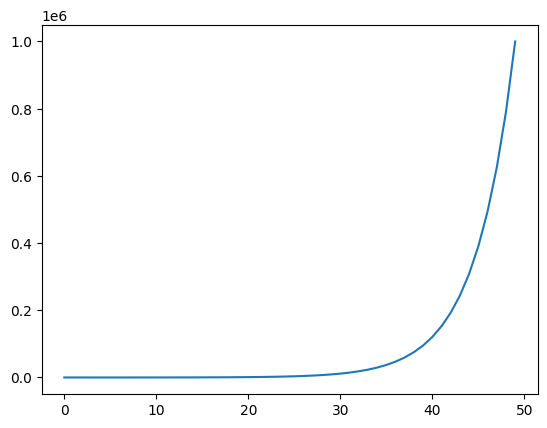

In [ ]:
# посмотрим на получившуюся последовательность на графике
plt.plot(series)

**Шаг 2**. Отдельные испытания в первой серии

In [ ]:
# обозначим точку отсчета
np.random.seed(42)

# во внешнем цикле пройдемся по сериям испытаний (их будет 50)
for i, trial in enumerate(series, 1):

  # выведем серию и количество бросков внутри нее
  print(f'Серия: {i}, количество испытаний: {trial}\n')

  # во внутреннем цикле будем бросать кость
  for n in range(trial):

    # запишем результат каждого броска
    result = np.random.randint(1, 7)

    # выведем номер броска и соответствующий результат
    print(f'Испытание: {n}, выпало число: {result}')

  # прервемся после первой серии
  break

Серия: 1, количество испытаний: 10

Испытание: 0, выпало число: 4
Испытание: 1, выпало число: 5
Испытание: 2, выпало число: 3
Испытание: 3, выпало число: 5
Испытание: 4, выпало число: 5
Испытание: 5, выпало число: 2
Испытание: 6, выпало число: 3
Испытание: 7, выпало число: 3
Испытание: 8, выпало число: 3
Испытание: 9, выпало число: 5


**Шаг 3**. Доля успешных исходов в первой серии

In [ ]:
# обозначим точку отсчета
np.random.seed(42)

# создадим счетчик для количества успешных испытаний
success = 0

# в двух циклах пройдемся по сериям и броскам в каждой серии
for trial in series:
  for n in range(trial):
    result = np.random.randint(1, 7)

    # если результат будет равен двум или трем
    if result == 2 or result == 3:

      # обновим счетчик
      success += 1

  # в конце каждой серии посчитаем долю успешных испытаний
  prob = success / trial

  print(f'Серия: {i}\n') # и выведем номер серии,
  print(f'Всего испытаний: {trial}') # общее количество испытаний,
  print(f'Успешных исходов: {success}') # количество и
  print(f'Эмпирическая вероятность: {prob}') # долю успешных испытаний

  # прервемся после окончания первой серии
  break

Серия: 1

Всего испытаний: 10
Успешных исходов: 5
Эмпирическая вероятность: 0.5


**Шаг 4**. Доля успешных испытаний в каждой серии

In [ ]:
# замерим время исполнения ячейки
%%time

# обозначим точку отсчета
np.random.seed(42)

# создадим счетчик для испытаний в каждой серии
success = 0

# а также список для записи результатов в пределах одной серии
prob_list = []

# пройдемся по сериям
for trial in series:

  # и броскам в каждой серии
  for n in range(trial):
    result = np.random.randint(1, 7)

    # посчитаем количество успешных бросков
    if result == 2 or result == 3:
      success += 1

  # вычислим долю успешных бросков
  prob = success / trial

  # добавим результат серии в список
  prob_list.append(prob)

  # обнулим счетчик для записи результата следующей серии
  success = 0

# после проведения всех серий испытаний выведем их количество
print(f'Проведено серий испытаний: {len(prob_list)}')

# а также эмпирическую вероятность отдельных серий
print(f'Эмпирическая вероятность каждой пятой серии: {np.round(prob_list[::5], 2)}')

Проведено серий испытаний: 50
Эмпирическая вероятность каждой пятой серии: [0.5  0.22 0.34 0.37 0.34 0.33 0.34 0.34 0.33 0.33]
CPU times: user 11 s, sys: 17.2 ms, total: 11.1 s
Wall time: 11.2 s


**Шаг 5**. Визуализация результата

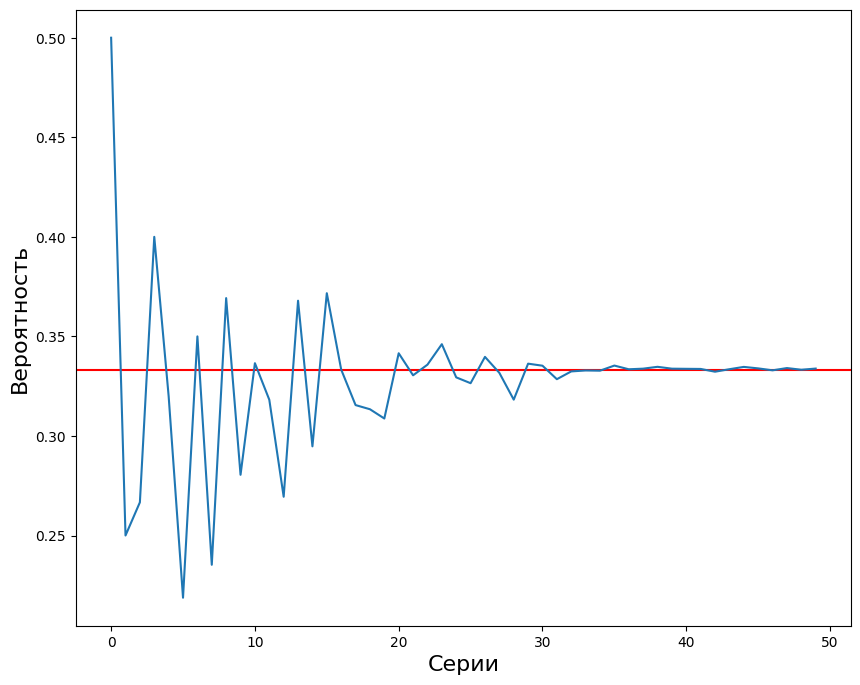

In [ ]:
# зададим размер графика
plt.figure(figsize = (10, 8))

# выведем горизонтальную линию теоретической вероятности
plt.axhline(y = 1/3, c = 'r')

# а также эмпирическую вероятность по результатам 50-ти серий испытаний
plt.plot(prob_list)

# добавим подписи
plt.xlabel('Серии', fontsize = 16)
plt.ylabel('Вероятность', fontsize = 16)

plt.show()

Векторизованный код

In [ ]:
%%time
np.random.seed(42)

# создадим новый список для записи результатов
prob_list_2 = []

# пройдемся по каждой из 50-ти серий
for trial in series:

  # вместо второго цикла, передадим количество бросков
  # непосредственно в функцию np.random.randint() через переменную trial
  # и запишем полученные данные в массив result
  result = np.random.randint(1, 7, trial)

  # в переменную success запишем сумму выпавших двоек или троек из массива result
  success = (result == 2).sum() + (result == 3).sum()

  # посчитаем долю успешных исходов
  prob = success / trial

  # и запишем ее в список
  prob_list_2.append(prob)

CPU times: user 52.2 ms, sys: 1.01 ms, total: 53.2 ms
Wall time: 53.4 ms


In [ ]:
# убедимся, что при одинаковой точке отсчета, результат будет идентичным
prob_list == prob_list_2

True

#### Задача о двух конвертах

In [ ]:
# зададим точку отсчета и
np.random.seed(50)

# количество испытаний
trials = 100000

# создадим список для записи результатов
outcomes = []

# с помощью цикла for
for trial in range(trials):

  # будем с одинаковой вероятностью генерировать числа 0 и 1
  outcome = np.random.randint(0, 2)

  # если выпадет ноль, то мы получим 2500 рублей
  if outcome == 0:

    # запишем этот результат в список
    outcomes.append(2500)

  else:

    # в противном случае, запишем 10000
    outcomes.append(10000)

# посчитаем среднее значение
sum(outcomes)/len(outcomes)

6249.475

#### Модель случайного блуждания

##### Случайное блуждание по числовой прямой

In [ ]:
# поставим точку отсчета
np.random.seed(2)

# создадим список и запишем в него исходную позицию
moves = [0]

# для наглядности запишем результат бросания монеты
coins = []

for x in range(5):

  # в цикле подбросим монету
  coin = np.random.randint(0, 2)

  # если выпадет 1, сдвинемся на одно значение от предыдущего результата
  # если выпадет 0, останемся на месте
  # запишем результат в список moves
  moves.append(moves[x] + coin)

  # также запишем результат подбрасывания монеты
  coins.append(coin)

In [ ]:
# посмотрим на сделанные шаги
moves

[0, 0, 1, 2, 2, 2]

In [ ]:
# посмотрим на результаты подбрасывания монеты
coins

[0, 1, 1, 0, 0]

##### Доедем ли мы из Москвы до Санкт-Петербурга?

Функция случайного блуждания

In [ ]:
# объявим функцию random_walk()
def random_walk():

  # создадим список для записи перемещений от Москвы до Санкт-Петербурга
  random_walk = [0]

  # в цикле из 100 итераций
  for m in range(99):

    # запишем последний достигнутый километр в переменную move
    move = random_walk[-1]

    # бросим кость
    dice = np.random.randint(1, 7)

    # если выпадет 1 или 2, сместимся на пять вперед
    if dice <= 2:
      move = move + 5

    # если выпадет 3 или 4, на пять назад, но в любом случае остановимся на нуле
    elif dice <= 4:
      move = max(0, move - 5)

    # если выпадет 5 или 6, бросим кость еще раз и умножим результат на пять,
    # это и будет следующее перемещение
    else:
      move = move + 5 * np.random.randint(1, 7)

    # в случае внезапной поломки вернемся на нулевой километр
    if np.random.rand() < 0.001:
      move = 0

    # запишем каждое движение в список random_walk
    random_walk.append(move)

  # вернем этот список при вызове функции
  return random_walk

Создание одного случайного блуждания

In [ ]:
# зададим точку отсчета
np.random.seed(42)

# вызовем функцию random_walk() и поместим результат в переменную rw
rw = random_walk()

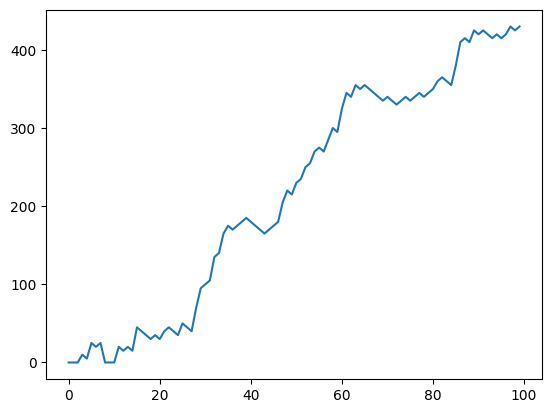

In [ ]:
# посмотрим на результат на графике
plt.plot(rw)

In [ ]:
# посмотрим на расстояние, которое удалось преодолеть
rw[-1]

430

Моделирование нескольких случайных блужданий

In [ ]:
# установим точку отсчета
np.random.seed(42)

# создадим список, в который будем помещать отдельные случайные блуждания
all_walks = []

# в цикле из 1000 итераций
for w in range(1000):

  # сгенерируем случайное блуждание
  rw = random_walk()

  # и поместим его в список all_walks
  all_walks.append(rw)

In [ ]:
# превратим список списков в массив Numpy и транспонируем,
all_walks_T = np.array(all_walks).T

# чтобы отдельное случайное блуждание стало столбцом
all_walks_T.shape

(100, 1000)

In [ ]:
# посмотрим на это в формате DataFrame
import pandas as pd

# для этого используем функцию pd.DataFrame()
df = pd.DataFrame(all_walks_T)

# и выведем последние пять строк
df.tail()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
95,415,645,785,565,355,595,545,640,665,585,...,745,715,560,375,690,690,505,605,515,645
96,420,655,790,580,360,590,550,670,670,590,...,740,745,555,390,695,695,530,635,510,675
97,430,665,815,600,355,585,545,675,690,610,...,735,750,575,415,690,705,535,630,515,685
98,425,660,820,605,370,580,540,680,695,605,...,730,745,570,420,695,725,540,625,530,715
99,430,665,815,610,365,585,535,685,700,600,...,755,755,575,415,690,730,545,650,540,730


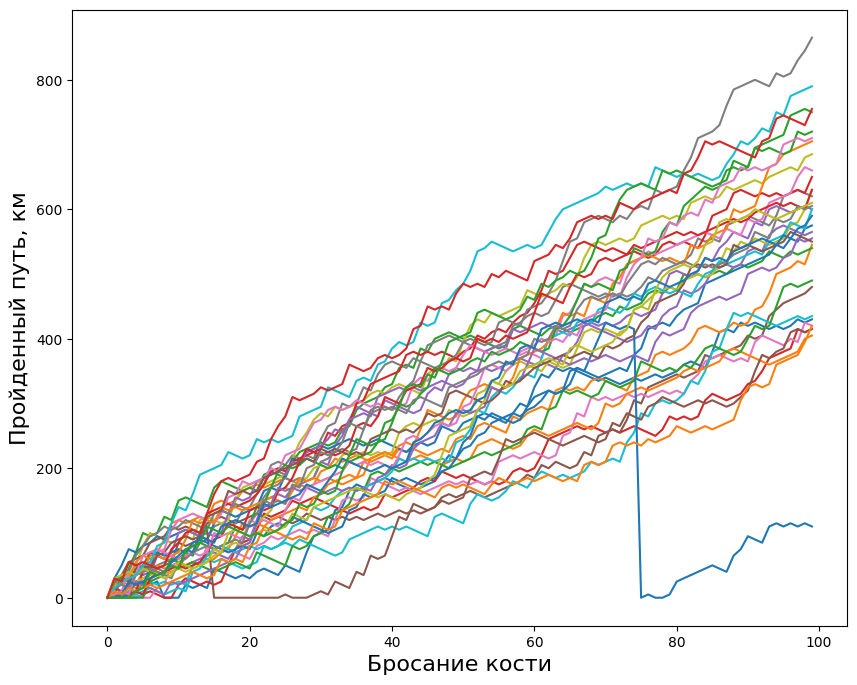

In [ ]:
# зададим размер графика
plt.figure(figsize = (10, 8))

# и выведем каждое 30-ое блуждание
plt.plot(all_walks_T[:,::30])

# добавим подписи
plt.xlabel('Бросание кости', fontsize = 16)
plt.ylabel('Пройденный путь, км', fontsize = 16)

plt.show()

Вероятность успешных поездок

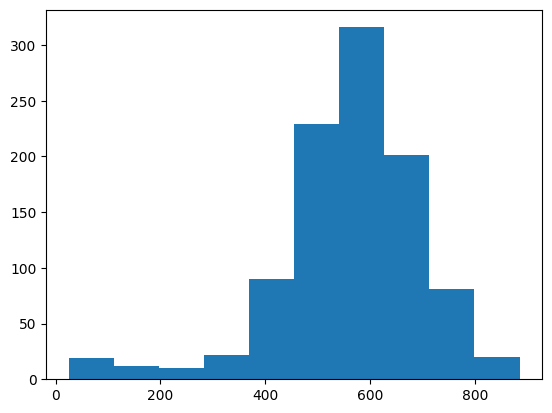

In [ ]:
# возьмем последнюю строку нашего массива
ends = all_walks_T[-1,:]

# и построим гистограмму с помощью plt.hist()
plt.hist(ends)
plt.show()

In [ ]:
# посмотрим на средний преодоленный путь
ends.mean()

561.415

In [ ]:
# посмотрим на долю успешных поездок
np.count_nonzero(ends >= 700)/len(ends)

0.128

### Вероятностное распределение



#### Дискретное распределение

##### Равномерное распределение

In [ ]:
# зададим точку отсчета
np.random.seed(42)

# бросим кость 100 000 раз
dice = np.random.randint(1, 7, 100000)

# выведем первые 10 результатов
dice[:10]

array([4, 5, 3, 5, 5, 2, 3, 3, 3, 5])

In [ ]:
# функция np.unique() возвращает перечень уникальных элементов массива
# и их количество при параметре return_counts = True
elements, counts = np.unique(dice, return_counts = True)

print(elements)
print(counts)

[1 2 3 4 5 6]
[16592 16799 16390 16776 16810 16633]


In [ ]:
# выполним поэлементное деление частоты каждого исхода на общее количество бросков
rel_freq = (counts / len(dice)).round(3)
rel_freq

array([0.166, 0.168, 0.164, 0.168, 0.168, 0.166])

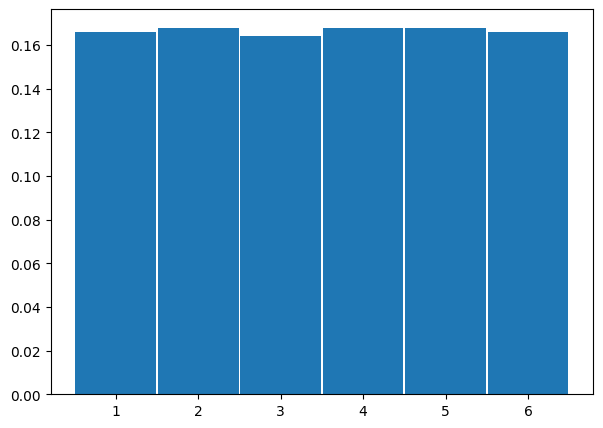

In [ ]:
# зададим размер графика
plt.figure(figsize = (7,5))

# передадим категории (элементы) и их относительную частоту
# параметр width контролирует ширину столбца
plt.bar(elements, rel_freq, width = 0.98)
plt.show()

In [ ]:
# убедимся, что сумма всех вероятностей равна единице
np.sum(rel_freq).round()

1.0

Матожидание

In [ ]:
# найдем сумму элементов, умноженных на их вероятности
np.sum(rel_freq * elements).round(2)

3.5

In [ ]:
# скалярное произведение дает тот же результат
np.dot(rel_freq, elements).round(2)

3.5

In [ ]:
# посмотрим на среднее значение сгенерированного распределения
np.mean(dice)

3.50312

Дисперсия

In [ ]:
# рассчитаем дисперсию
((6)**2 - 1)/12

2.9166666666666665

In [ ]:
# сравним с нашим распределением
np.var(dice)

2.9156702656

##### Распределение Бернулли

In [ ]:
# объявим функцию bernoulli() с параметрами p, iter
def bernoulli(p, iter = 1):

  # создадим пустой массив
  result = np.array([])

  # в цикле с количеством итераций iter
  for i in range(iter):

      # если значение np.random.rand() в диапазоне [0, 1) меньше или равно p
      if np.random.rand() <= p:

          # запишем в массив result единицу
          result = np.append(result, 1)

      else:

          # в противном случае, запишем ноль
          result = np.append(result, 0)

  # в результате выполнения функции вернем массив result
  return result

In [ ]:
# вызовем функцию
res = bernoulli(0.7, 10000)

# выясним количество нулей и единиц в получившемся массиве
values, counts = np.unique(res, return_counts = True)

# выведем значения, частоту и относительную частоту
values, counts, counts / len(res)

(array([0., 1.]), array([3015, 6985]), array([0.3015, 0.6985]))

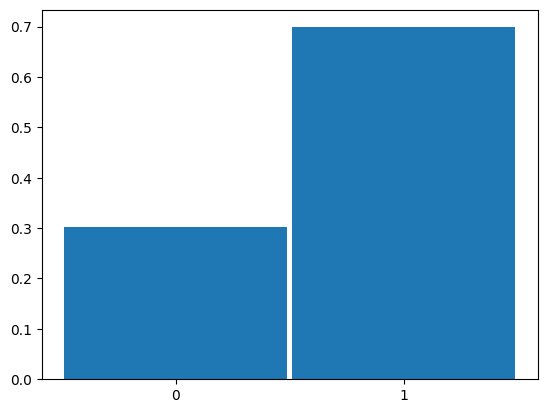

In [ ]:
# используем столбчатую диаграмму, в качестве названия столбцов передадим '0' и '1',
# в качестве высоты - относительную частоту значений
plt.bar(['0', '1'], counts / len(res), width = 0.98)
plt.show()

##### Биномиальное распределение

In [ ]:
# зададим точку отсчета
np.random.seed(42)

# и проведем 1 000 000 экспериментов (size) по три подбрасывания монеты (n)
# с вероятностью выпадения орла 0,7 (p)
res = np.random.binomial(n = 3, p = 0.7, size = 1000000)

# посмотрим на первые 10 значений
res[:10]

array([2, 1, 2, 2, 3, 3, 3, 1, 2, 2])

In [ ]:
# посчитаем, сколько раз выпали 0, 1, 2 или 3 орла
_, counts = np.unique(res, return_counts = True)

# посмотрим на относительную частоту каждого из значений
counts / len(res)

array([0.027142, 0.188935, 0.441131, 0.342792])

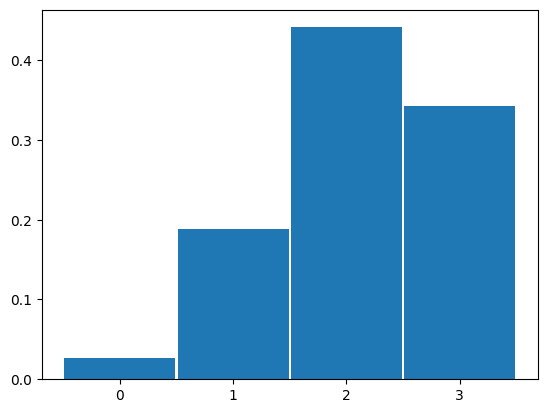

In [ ]:
# построим график распределения
plt.bar(['0', '1', '2', '3'], counts / len(res), width = 0.98)
plt.show()

In [ ]:
# рассчитаем среднее значение
np.mean(res)

2.099573

In [ ]:
# рассчитаем дисперсию
np.var(res)

0.6303802176710002

In [ ]:
np.random.seed(42)

# функция np.random.binomial() позволяет имитировать эксперимент Бернулли
# достаточно поставить n = 1
res = np.random.binomial(n = 1, p = 0.7, size = 1000000)

# выясним количество нулей и единиц в получившемся массиве
_, counts = np.unique(res, return_counts = True)

# посмотрим на относительную частоту значений
counts / len(res)

array([0.30021, 0.69979])

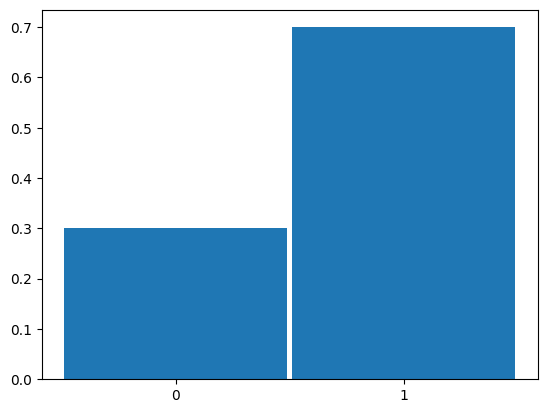

In [ ]:
# посмотрим на результат на графике
plt.bar(['0', '1'], counts / len(res), width = 0.98)
plt.show()

#### Непрерывное распределение

##### Равномерное распределение

Ожидание автобуса, приходящего каждые 12 минут

In [ ]:
# создадим распределение с параметрами a = 0 и b = 12
# повторим экспермиент 1 000 000 раз
res = np.random.uniform(0, 12, 1000000)

# посмотрим на первые десять значений
res[:10]

array([ 7.14186749,  4.37660571,  0.06450744,  6.73305271, 10.75884493,
        6.38060282,  9.36585218,  1.94345171,  1.64757201, 10.72732251])

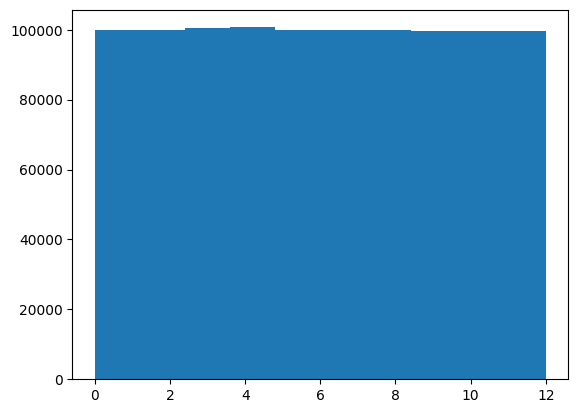

In [ ]:
# выведем результат с помощью гистограммы
plt.hist(res)
plt.show()

In [ ]:
# посмотрим на среднее значение
np.mean(res)

5.993743863584736

In [ ]:
# и дисперсию
np.var(res)

11.986689948141048

In [ ]:
# разделим количество значений <= 7 на общее количество значений
len(res[res <= 7])/len(res)

0.584527

Разница между  `np.random.random()`, `np.random.rand()` и `np.random.uniform()`

In [ ]:
# создадим массив 2 x 3 в интервале от [0, 1)
np.random.seed(42)

# для этого передадим параметры в виде кортежа
np.random.random((2, 3))

array([[0.37454012, 0.95071431, 0.73199394],
       [0.59865848, 0.15601864, 0.15599452]])

In [ ]:
# функция np.random.rand() практически ничем не отличается от np.random.random(),
# единственное отличие - размеры массива передаются отдельными параметрами, а не кортежем
np.random.seed(42)
np.random.rand(2, 3)

array([[0.37454012, 0.95071431, 0.73199394],
       [0.59865848, 0.15601864, 0.15599452]])

In [ ]:
# сгенерируем одно значение из равномерного распределения в интервале [0, 9)
np.random.uniform(9)

8.535331102654403

In [ ]:
# создадим двумерный массив 2 х 5 со значениями в промежутке [0, 1)
np.random.seed(42)
np.random.uniform(size = (2, 5))

array([[0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864],
       [0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258]])

##### Нормальное распределение

###### Визуализация

In [ ]:
# зададим точку отсчета
np.random.seed(42)

# создадим 100 000 значений нормально распределенной величины с матожиданием 180 см и СКО 10 см
height_men = np.round(np.random.normal(180, 10, 100000))

# создадим еще одно распределение, но матожидание будет равно 160 см
height_women = np.round(np.random.normal(160, 10, 100000))

In [ ]:
# посмотрим на первые десять значений
print(height_men[:10])
print(height_women[:10])

[185. 179. 186. 195. 178. 178. 196. 188. 175. 185.]
[170. 148. 166. 154. 157. 160. 159. 143. 174. 171.]


Гистограмма

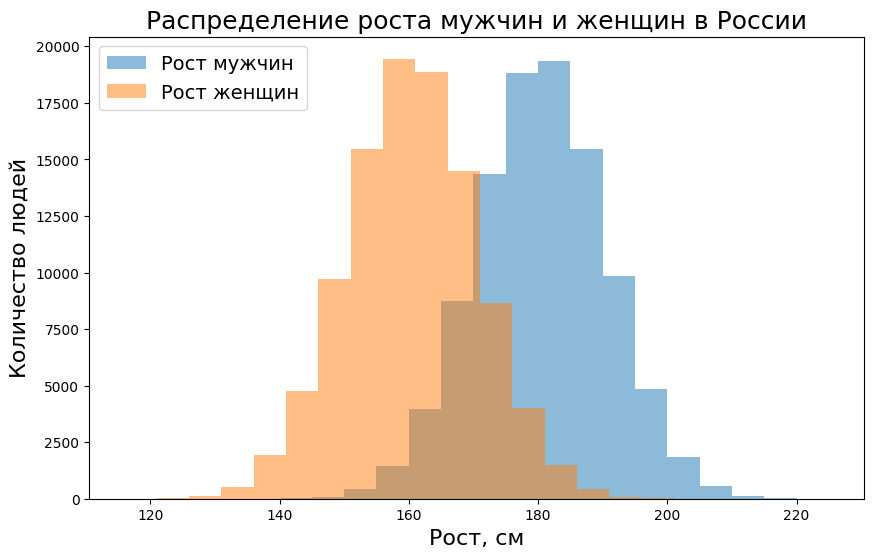

In [ ]:
# выведем результат с помощью гистограммы
plt.figure(figsize = (10,6))

# зададим 18 интервалов (bin) и уровень прозрачности графиков
plt.hist(height_men, 18, alpha = 0.5, label = 'Рост мужчин')
plt.hist(height_women, 18, alpha = 0.5, label = 'Рост женщин')

# пропишем расположение и размер шрифта легенды
plt.legend(loc = 'upper left', prop = {'size': 14})

# добавим подписи
plt.xlabel('Рост, см', fontsize = 16)
plt.ylabel('Количество людей', fontsize = 16)
plt.title('Распределение роста мужчин и женщин в России', fontsize = 18)

plt.show()

График функции плотности

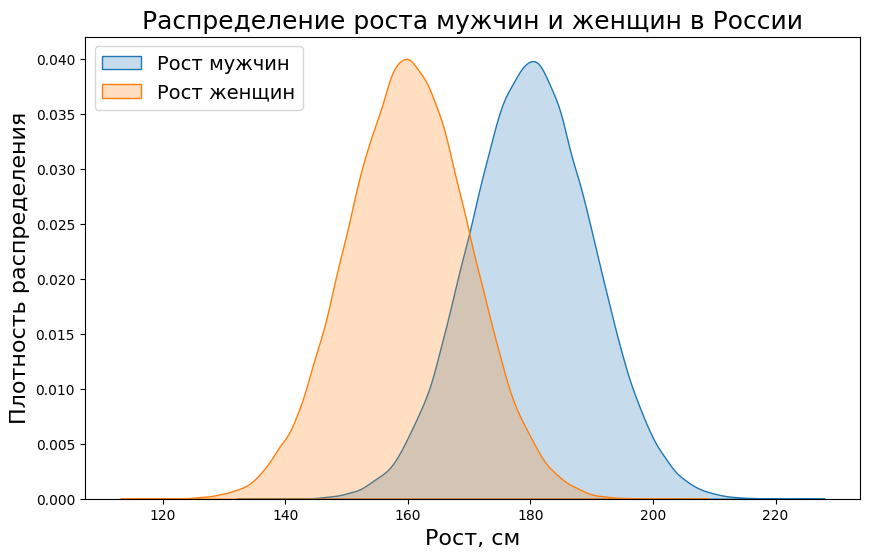

In [ ]:
# импортируем библиотеку seaborn
import seaborn as sns

# зададим размер графиков
plt.figure(figsize = (10,6))

# и построим график функции плотности
sns.kdeplot(height_men, fill = True, label = 'Рост мужчин')
sns.kdeplot(height_women, fill = True, label = 'Рост женщин')

# пропишем расположение и размер шрифта легенды
plt.legend(loc = 'upper left', prop = {'size': 14})

# добавим подписи
plt.xlabel('Рост, см', fontsize = 16)
plt.ylabel('Плотность распределения', fontsize = 16)
plt.title('Распределение роста мужчин и женщин в России', fontsize = 18)

plt.show()

Boxplot

In [ ]:
# boxplot, как и многие другие графики, удобно строить из библиотеки Pandas
import pandas as pd

# создадим датафрейм из словаря, включающего два массива с данными о росте
data = pd.DataFrame({'Мужчины' : height_men, 'Женщины' : height_women})
data.head()

,Мужчины,Женщины
0,185.0,170.0
1,179.0,148.0
2,186.0,166.0
3,195.0,154.0
4,178.0,157.0


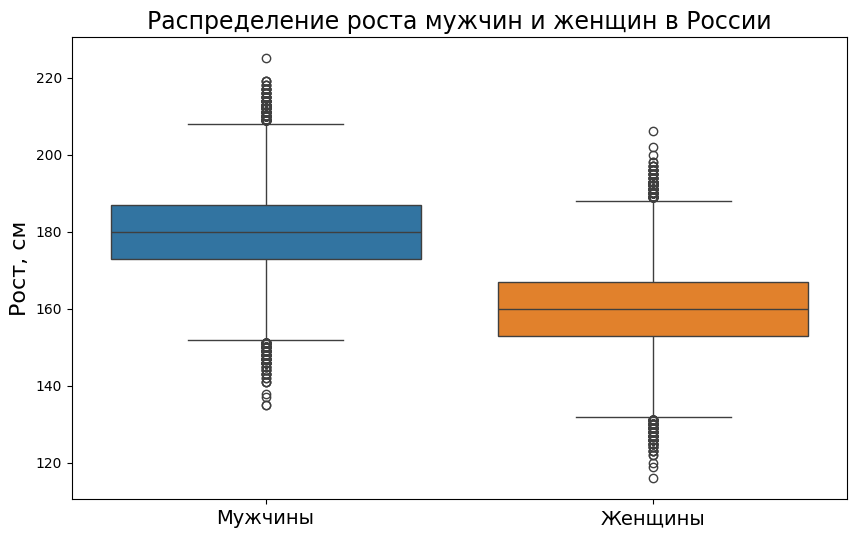

In [ ]:
# зададим размер графика
plt.figure(figsize = (10,6))

# и построим два вертикальных boxplots, передав датафрейм с данными в параметр data
sns.boxplot(data = data)

# дополнительно укажем размер подписей каждого из графиков по оси x
plt.xticks(fontsize = 14)
# подпись к оси y
plt.ylabel('Рост, см', fontsize = 16)
# и заголовок графика
plt.title('Распределение роста мужчин и женщин в России', fontsize = 17)

plt.show()

Boxplot и гистограмма

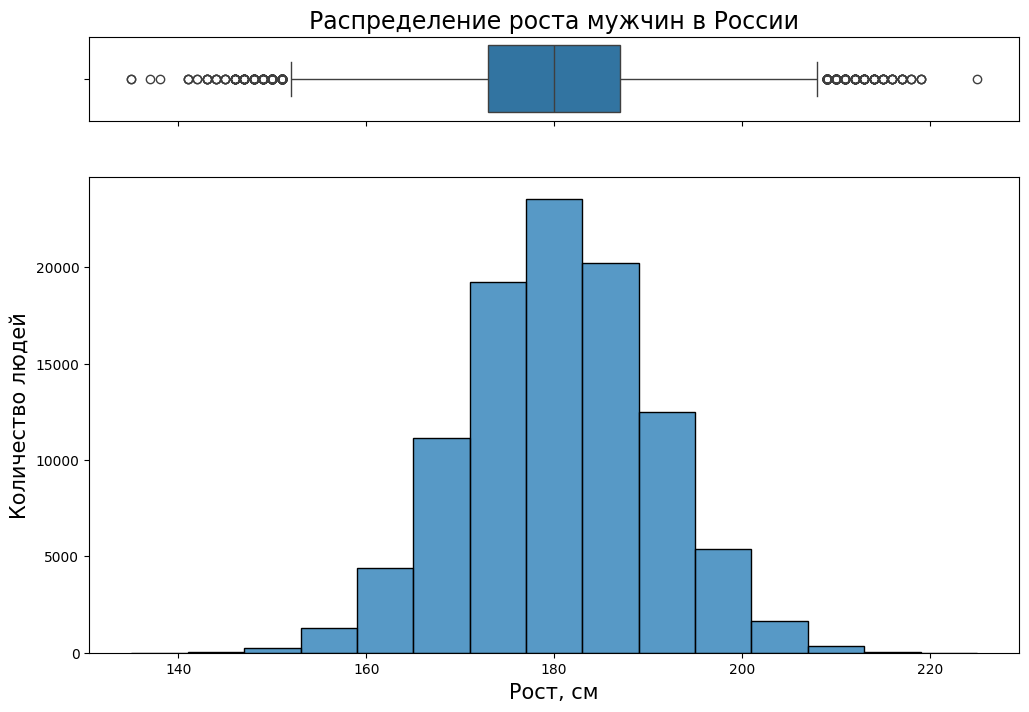

In [ ]:
# создадим два подграфика
f, (ax_box, ax_hist) = plt.subplots(nrows = 2, # из двух строк
                                    ncols = 1, # и одного столбца
                                    sharex = True, # оставим только нижние подписи к оси x
                                    gridspec_kw = {'height_ratios': (.15, .85)}, # зададим разную высоту строк
                                    figsize = (12,8)) # зададим размер графика

# в первом подграфике построим boxplot
sns.boxplot(x = height_men, ax = ax_box)
# во втором гистограмму
sns.histplot(data = height_men, bins = 15, ax = ax_hist)

# зададим заголовок и подписи к осям
ax_box.set_title('Распределение роста мужчин в России', fontsize = 17)
ax_hist.set_xlabel('Рост, см', fontsize = 15)
ax_hist.set_ylabel('Количество людей', fontsize = 15)

plt.show()

###### Расчет вероятности

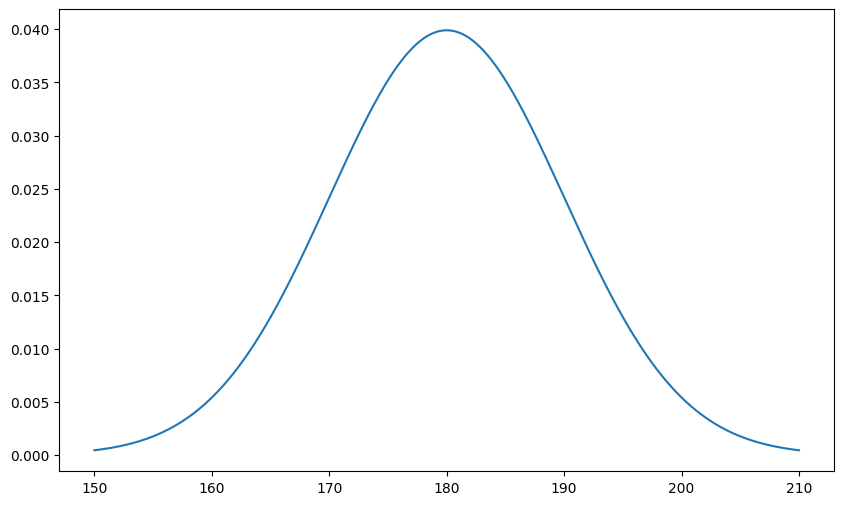

In [ ]:
# импортируем объект norm из модуля stats библиотеки scipy
from scipy.stats import norm

# зададим размер графика
plt.figure(figsize = (10,6))

# пропишем среднее значение и СКО
mean, std = 180, 10

# создадим пространство из 1000 точек в диапазоне +/- трех СКО от среднего значения
x = np.linspace(mean - 3 * std, mean + 3 * std, 1000)

# рассчитаем значения по оси y с помощью метода .pdf()
# т.е. функции плотности распределения
f = norm.pdf(x, mean, std)

# и построим график
plt.plot(x, f)

plt.show()

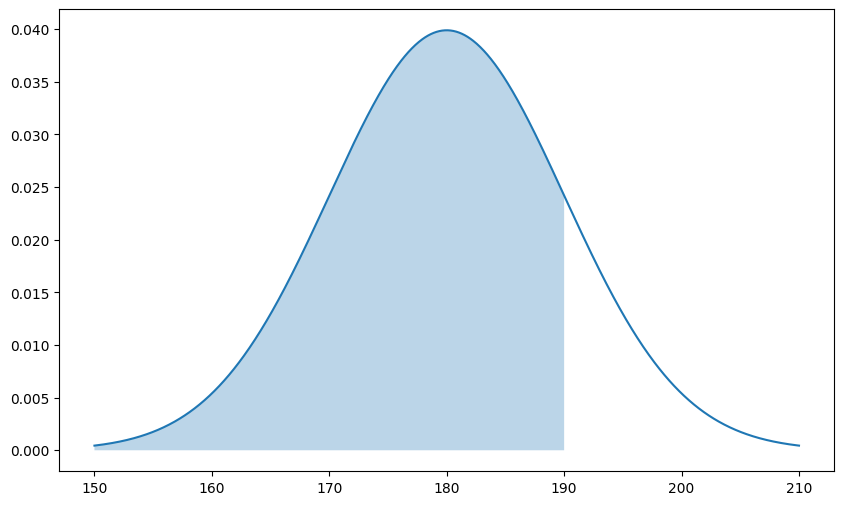

In [ ]:
# зададим размер графика
plt.figure(figsize = (10,6))

# пропишем среднее значение и СКО
mean, std = 180, 10

# создадим пространство из 1000 точек в диапазоне +/- трех СКО от среднего значения
x = np.linspace(mean - 3 * std, mean + 3 * std, 1000)

# рассчитаем значения по оси y с помощью метода .pdf()
# т.е. функции плотности распределения
f = norm.pdf(x, mean, std)

# и построим график
plt.plot(x, f)

# дополнительно создадим точки на оси х для закрашенной области
px = np.linspace(mean - 3 * std, 190, 1000)

# и заполним в пределах этих точек по оси x пространство
# от кривой нормального распределения до оси y = 0
plt.fill_between(px, norm.pdf(px, mean, std), alpha = 0.3)

# выведем оба графика
plt.show()

In [ ]:
# передадим методу .cdf() границу (рост), среднее значение (loc) и СКО (scale)
area = norm.cdf(190, loc = 180, scale = 10)

# на выходе мы получим площадь под кривой
area

0.8413447460685429

In [ ]:
# с помощью метода .ppf() можно узнать значение (рост) по площади
height = norm.ppf(area, loc = 180, scale = 10)
height

190.0

In [ ]:
# теперь рассчитаем вероятность встретить человека выше 190 см
1 - norm.cdf(190, loc = 180, scale = 10)

0.15865525393145707

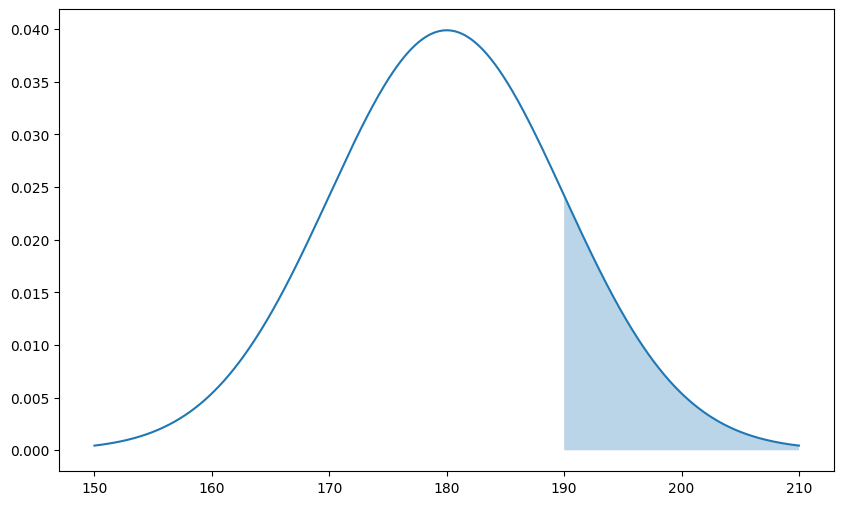

In [ ]:
# зададим размер графика
plt.figure(figsize = (10,6))

# пропишем среднее значение и СКО
mean, std = 180, 10

# создадим пространство из 1000 точек в диапазоне +/- трех СКО от среднего значения
x = np.linspace(mean - 3 * std, mean + 3 * std, 1000)

# рассчитаем значения по оси y с помощью метода .pdf()
# т.е. функции плотности распределения
f = norm.pdf(x, mean, std)

# и построим график
plt.plot(x, f)

# дополнительно создадим точки на оси х для закрашенной области
px = np.linspace(190, mean + 3 * std, 1000)

# и заполним в пределах этих точек по оси x пространство
# от кривой нормального распределения до оси y = 0
plt.fill_between(px, norm.pdf(px, mean, std), alpha = 0.3)

# выведем оба графика
plt.show()

In [ ]:
# рассчитаем меньшую площадь до нижней границы
lowerbound = norm.cdf(170, loc = 180, scale = 10)

# рассчитаем большую площадь до верхней границы
upperbound = norm.cdf(190, loc = 180, scale = 10)

# вычтем меньшую площадь из большей
upperbound - lowerbound

0.6826894921370859

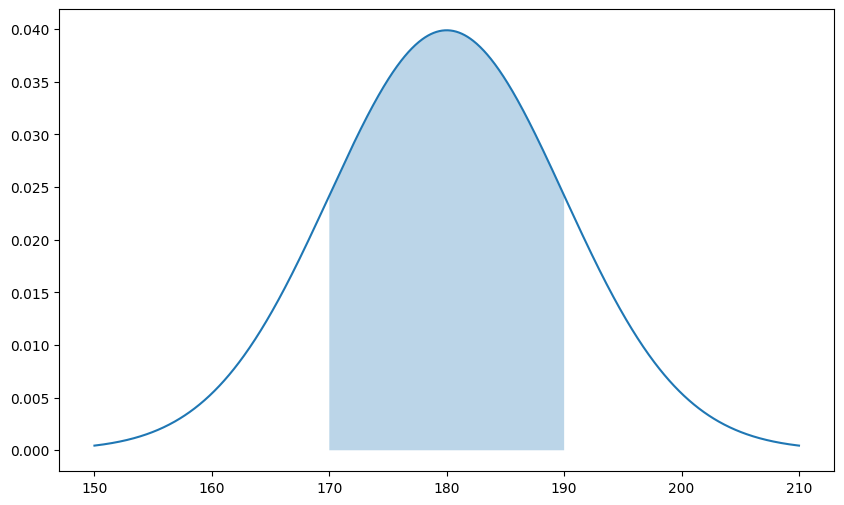

In [ ]:
# зададим размер графика
plt.figure(figsize = (10,6))

# пропишем среднее значение и СКО
mean, std = 180, 10

# создадим пространство из 1000 точек в диапазоне +/- трех СКО от среднего значения
x = np.linspace(mean - 3 * std, mean + 3 * std, 1000)

# рассчитаем значения по оси y с помощью метода .pdf()
# т.е. функции плотности распределения
f = norm.pdf(x, mean, std)

# и построим график
plt.plot(x, f)

# дополнительно создадим точки на оси х для закрашенной области
px = np.linspace(170, 190, 1000)

# и заполним в пределах этих точек по оси x пространство
# от кривой нормального распределения до оси y = 0
plt.fill_between(px, norm.pdf(px, mean, std), alpha = 0.3)

# выведем оба графика
plt.show()

In [ ]:
# разделим количество людей с ростом <= 190 на общее количество наблюдений
len(height_men[height_men <= 190])/len(height_men)

0.85195

###### pdf и cdf

Интегрирование

$$ D(x) = \int_{-\infty}^{x} P(x) dx $$

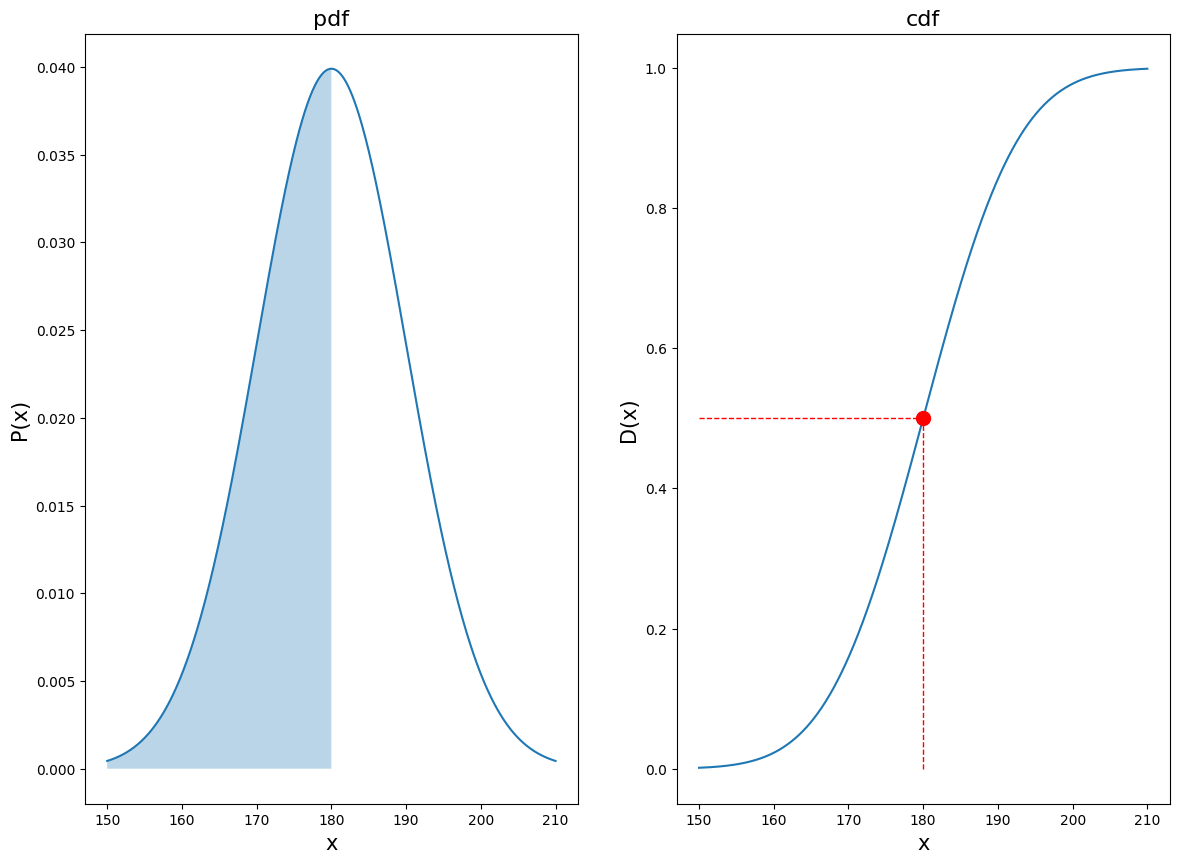

In [ ]:
# зададим размер графика
plt.figure(figsize = (14,10))

# определим среднее значение и СКО
mean, std = 180, 10

# зададим последовательность точек на оси x
x = np.linspace(mean - 3 * std, mean + 3 * std, 1000)

# найдем значения функции плотности
y1 = norm.pdf(x, mean, std)

# и функции распределения
y2 = norm.cdf(x, mean, std)

# на левом графике (row 1, col 2, index 1)
plt.subplot(1, 2, 1)

# построим функцию плотности
plt.plot(x, y1)

# и заполним пространство под кривой вплоть до точки x = 180
px = np.linspace(mean - 3 * std, 180, 1000)
plt.fill_between(px, norm.pdf(px, mean, std), alpha = 0.3)

# добавим заголовок и подписи к осям
plt.title('pdf', fontsize = 16)
plt.xlabel('x', fontsize = 15)
plt.ylabel('P(x)', fontsize = 15)

# на правом графике (row 1, col 2, index 2)
plt.subplot(1, 2, 2)

# построим функцию распределения
plt.plot(x, y2)

# а также горизонтальную и вертикальную пунктирные линии,
plt.hlines(y = 0.5, xmin = 150, xmax = 180, linewidth = 1, color = 'r', linestyles = '--')
plt.vlines(x = 180, ymin = 0, ymax = 0.5, linewidth = 1, color = 'r', linestyles = '--')

# которые сойдутся в точке (180, 0.5)
plt.plot(180, 0.5, marker = 'o', markersize = 10, markeredgecolor = 'r', markerfacecolor = 'r')

# добавим заголовок и подписи к осям
plt.title('cdf', fontsize = 16)
plt.xlabel('x', fontsize = 15)
plt.ylabel('D(x)', fontsize = 15)

plt.show()

Дифференцирование

$$ P(x) = D'(x) $$

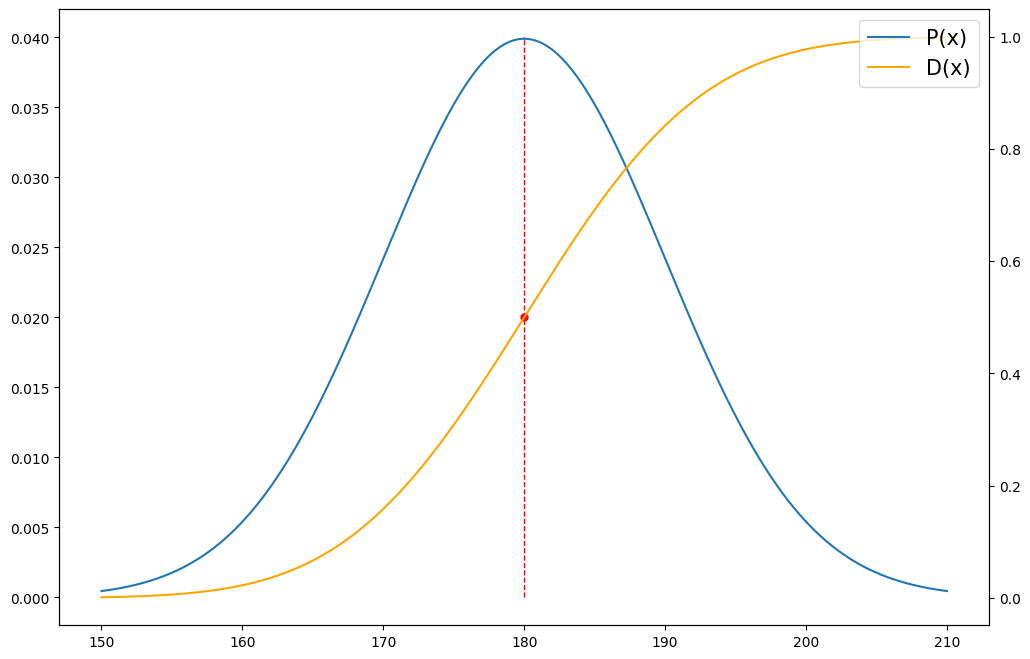

In [ ]:
# зададим функции pdf и cdf на оси x
x = np.linspace(mean - 3 * std, mean + 3 * std, 1000)

# при этом возникает проблема: по оси y них разный масштаб
y1 = norm.pdf(x, mean, std)
y2 = norm.cdf(x, mean, std)

# эту проблему можно решить через функции subplots() и twinx()
# создадим сетку из одной ячейки
fig, ax_left = plt.subplots(nrows = 1, ncols = 1, figsize = (12,8))

# создадим новую ось с правой стороны
ax_right = ax_left.twinx()

# на оси x и левой оси y построим график функции плотности (pdf)
ax_left.plot(x, y1, label = 'P(x)')

# на оси x и правой оси y построим график функции распределения (cdf)
ax_right.plot(x, y2, color = 'orange', label = 'D(x)')

# также построим вертикальную прямую и точку
ax_left.vlines(x = 180, ymin = 0, ymax = 0.040, linewidth = 1, color = 'r', linestyles = '--')
ax_left.plot(180, 0.020, marker = 'o', markersize = 5, markeredgecolor = 'r', markerfacecolor = 'r')

# из-за двух осей с легендой придется повозиться
fig.legend(loc = 'upper right',
           bbox_to_anchor = (1,1),
           bbox_transform = ax_right.transAxes,
           prop = {'size': 15})

plt.show()

Нахождение вероятности через интеграл

In [ ]:
# воспользуемся модулем integrate библиотеки scipy
import scipy.integrate as integrate

# зададим среднее значение и СКО
mu, sigma = 180, 10

# и границы интервала от 190 до бесконечности
lowerbound = 190
upperbound = np.inf

# функция quad() в качестве первого аргумента ожидает функцию для интегрирования
# напишем функцию gauss() с одним параметром
def gauss(x):
    return norm.pdf(x, mu, sigma)

# передадим в функцию quad() функцию Гаусса, а также нижний и верхний пределы
# поместим первое выводимое значение в переменную integral
integral = integrate.quad(gauss, lowerbound, upperbound)[0]

# так как мы получили вероятность от 190 см и выше (то есть площадь справа)
# для нахождения вероятности не более 190 см результат нужно вычесть из единицы
1 - integral

0.8413447460685429

###### Выборки

In [ ]:
# возьмем вот такой мешок с разноцветными шарами
bag = ['red', 'yellow', 'green', 'gray', 'black', 'orange', 'white', 'blue', 'brown', 'pink']

In [ ]:
np.random.seed(42)

# выберем с возвращением восемь шаров
np.random.choice(bag, 8)

array(['white', 'gray', 'blue', 'black', 'white', 'pink', 'green',
       'white'], dtype='<U6')

In [ ]:
np.random.seed(42)

# сделаем то же самое, только возвращать шары не будем
np.random.choice(bag, 8, replace = False)

array(['brown', 'yellow', 'orange', 'red', 'blue', 'green', 'pink',
       'black'], dtype='<U6')

In [ ]:
np.random.seed(42)

# выберем 5 чисел из массива от 0 до 9
# "под капотом" массив из 10 чисел формируется с помощью np.arange(10)
np.random.choice(10, 5)

array([6, 3, 7, 4, 6])

###### ЦПТ

Пример скошенного вправо распределения

In [ ]:
# скошенное распределение мы будем строить
# с помощью объекта skewnorm модуля stats библиотеки scipy
from scipy.stats import skewnorm

# сгенерируем массив с данными о зарплате, задав искуссвенные параметры
salaries = skewnorm.rvs(a = 20, # скошенность (skewness)
                        loc = 20, # среднее значение без учета скошенности
                        scale = 80, # отклонение от среднего
                        size = 100000, # размер генерируемого массива
                        random_state = 42) # воспроизводимость результата

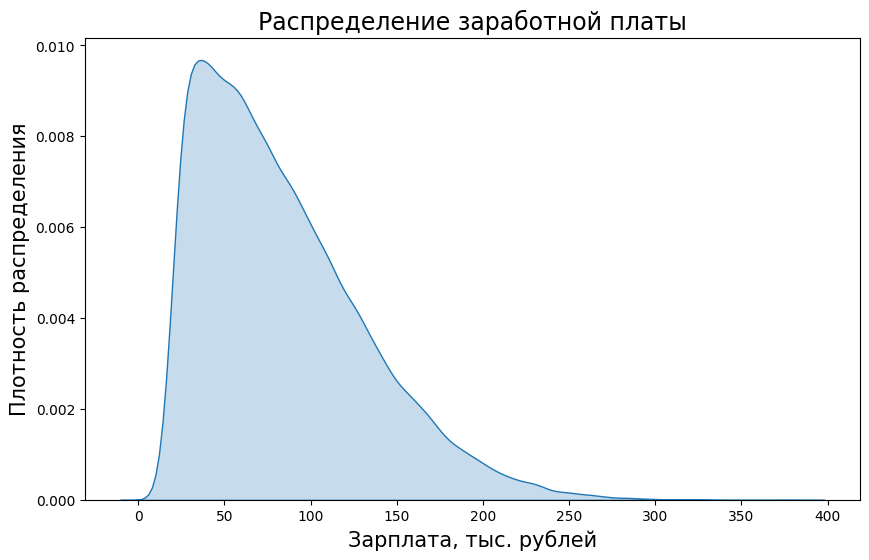

In [ ]:
# зададим размер графика
plt.figure(figsize = (10,6))

# и построим график функции плотности
sns.kdeplot(salaries, fill = True)

# добавим подписи
plt.xlabel('Зарплата, тыс. рублей', fontsize = 15)
plt.ylabel('Плотность распределения', fontsize = 15)
plt.title('Распределение заработной платы', fontsize = 17)

plt.show()

In [ ]:
# посмотрим на среднее значение
np.mean(salaries)

83.84511076271755

In [ ]:
# посмотрим на медиану
np.median(salaries)

74.07573752156253

In [ ]:
# рассчитаем СКО
np.std(salaries)

48.366511941114176

Выборки с возвращением

In [ ]:
# зададим точку отсчета
np.random.seed(42)

# создадим список, в который будем записывать выборочные средние
sample_means = []

# зададим количество и размер выборок
n_samples = 1000
sample_size = 30

# в цикле будем формировать выборки
for i in range(n_samples):

  # путем отбора нужного количества элементов из генеральной совокупности
  sample = np.random.choice(salaries, sample_size, replace = False)

  # для каждой выборки рассчитаем среднее значение и поместим в список выборочных средних
  sample_means.append(np.mean(sample))

# убедимся, что сформировали нужно количество выборок
len(sample_means)

1000

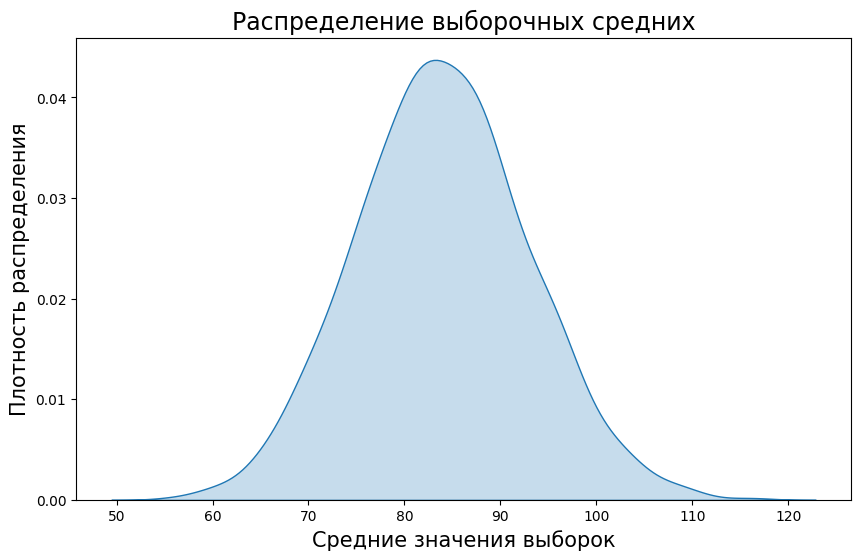

In [ ]:
# зададим размер графика
plt.figure(figsize = (10,6))

# и построим график функции плотности
sns.kdeplot(sample_means, fill = True)

# добавим подписи
plt.xlabel('Средние значения выборок', fontsize = 15)
plt.ylabel('Плотность распределения', fontsize = 15)
plt.title('Распределение выборочных средних', fontsize = 17)

plt.show()

In [ ]:
# посмотрим к чему, согласно ЦПТ, должны стремиться среднее и СКО выборочного распределения
np.mean(salaries), np.std(salaries)/np.sqrt(sample_size)

(83.84511076271755, 8.830476539330403)

In [ ]:
# и сравним с фактическими данными
np.mean(sample_means), np.std(sample_means)

(83.93586714203595, 8.94762726282006)

Выборки без возвращения

In [ ]:
# объявим собственную функцию для формирования распределения выборочных средних
def sample_means(data, n_samples, sample_size, replace = True, random_state = None):

  # создадим список, в который будем записывать выборочные средние
  sample_means = []

  # пропишем воспроизводимость
  np.random.seed(random_state)

  # в цикле будем формировать выборки
  for i in range(n_samples):

    # путем отбора нужного количества элементов из генеральной совокупности
    sample = np.random.choice(data, sample_size, replace = False)

    # для каждой выборки рассчитаем среднее значение и поместим в список выборочных средних
    sample_means.append(np.mean(sample))

    # если указано, что выборки делаются без возвращения
    if replace == False:

      # удалим эту выборку из данных о зарплате
      data = np.array(list(set(data) - set(sample)))

  # вернем список с выборочными средними
  return sample_means

In [ ]:
# сформируем 100 выборок без возвращения по 30 элементов в каждой
res = sample_means(salaries, 100, 30, replace = False, random_state = 42)

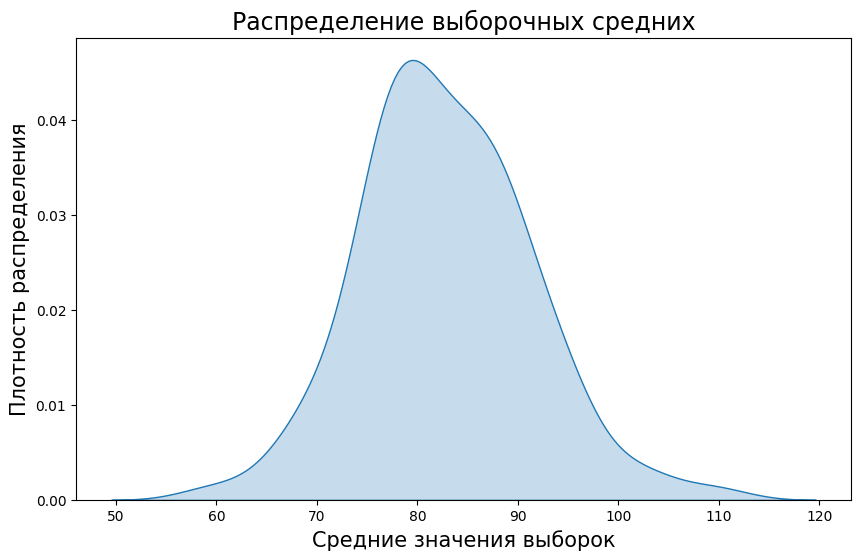

In [ ]:
# зададим размер графика
plt.figure(figsize = (10,6))

# и построим график функции плотности
sns.kdeplot(res, fill = True)

# добавим подписи
plt.xlabel('Средние значения выборок', fontsize = 15)
plt.ylabel('Плотность распределения', fontsize = 15)
plt.title('Распределение выборочных средних', fontsize = 17)

plt.show()

Распределение выборочных средних при разном количестве и размере выборок

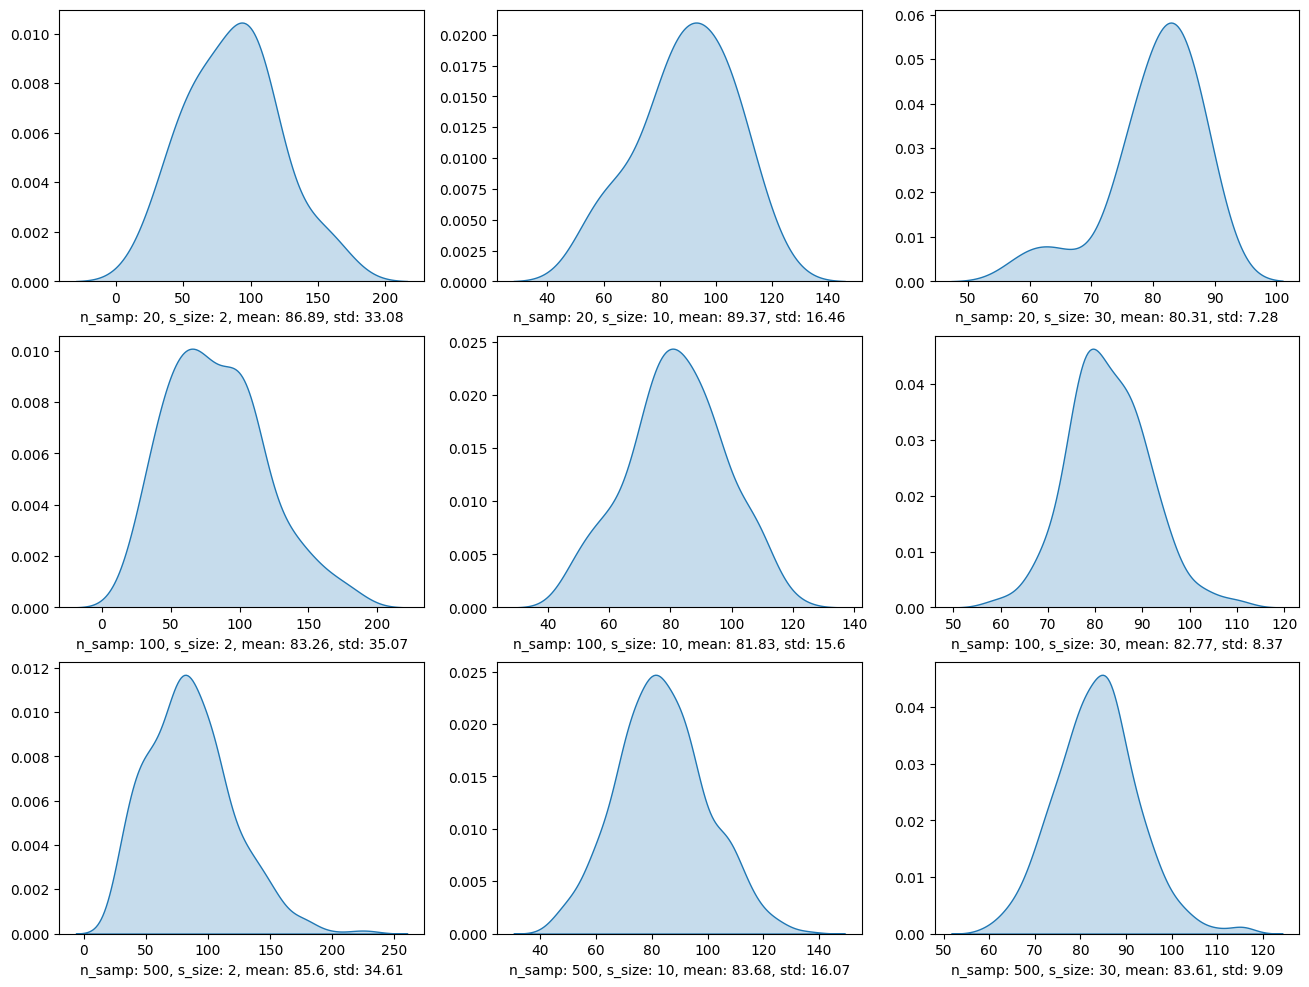

In [ ]:
# создадим сетку подграфиков 3 x 3
fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = (16,12))

# списки с разным количеством
number_of_samples_list = [20, 100, 500]
# и размером выборок
sample_size_list = [2, 10, 30]

# кроме этого, создадим списки для учета получившихся
# средних значений
mean_list = []
# и СКО
std_list = []

# по строкам сетки 3 x 3 разместим разное количество выборок
for i, n_samples in enumerate(number_of_samples_list):
  # по столбцам разный размер выборки
  for j, sample_size in enumerate(sample_size_list):

    # на каждой итерации будем генерировать "свежую" генеральную совокупность
    salaries = skewnorm.rvs(a = 20, loc = 20, scale = 80, size = 100000, random_state = 42)

    # и создавать распределение с заданными параметрами
    res = sample_means(salaries, n_samples, sample_size, replace = False, random_state = 42)

    # кроме того, мы вычисляем среднее значение и СКО
    mean = np.mean(res).round(2)
    std = np.std(res).round(2)

    # и записываем их в соответствующие списки
    mean_list.append(mean)
    std_list.append(std)

    # помещаем график плотности распределения в "ячейку" с координатами [i, j],
    sns.kdeplot(res, fill = True, ax = ax[i, j])
    # а под графиком выводим количество выборок, размер выборки, среднее значение и СКО
    ax[i, j].set_xlabel('n_samp: {}, s_size: {}, mean: {}, std: {}'.format(n_samples, sample_size, mean, std))
    # подпись к оси y оставляем пустой
    ax[i, j].set_ylabel('')

# выведем результат
plt.show()

In [ ]:
# вновь создадим генеральную совокупность
salaries = skewnorm.rvs(a = 20, loc = 20, scale = 80, size = 100000, random_state = 42)

# в словарь sampling_distributions поместим
sampling_distributions = {
    # количество выборок в каждом из девяти распределений
    'Number_of_samples' : np.repeat(number_of_samples_list, 3),
    # размер каждой выборки
    'Sample_size' : sample_size_list * 3,
    # среднее значение генеральной совокупности
    'Pop_mean' : [np.mean(salaries)] * 9,
    # фактическое среднее значение каждого распределения
    'Actual_mean' : mean_list,
    # расчетное СКО (в соответствии с ЦПТ)
    'Expected_std' : [np.std(salaries) / np.sqrt(n) for n in sample_size_list * 3],
    # фактическое СКО каждого распределения
    'Actual_std' : std_list
}

# превратим словарь в датафрейм и округлим значения
pd.DataFrame(sampling_distributions).round(2).astype(str)

,Number_of_samples,Sample_size,Pop_mean,Actual_mean,Expected_std,Actual_std
0,20,2,83.85,86.89,34.2,33.08
1,20,10,83.85,89.37,15.29,16.46
2,20,30,83.85,80.31,8.83,7.28
3,100,2,83.85,83.26,34.2,35.07
4,100,10,83.85,81.83,15.29,15.6
5,100,30,83.85,82.77,8.83,8.37
6,500,2,83.85,85.6,34.2,34.61
7,500,10,83.85,83.68,15.29,16.07
8,500,30,83.85,83.61,8.83,9.09


###### Стандартное нормальное распределение

In [ ]:
# воспользуемся векторизацией и трансляцией кода
# для приведения распределения к стандартному виду
height_men_standard = (height_men - np.mean(height_men))/np.std(height_men)
height_men_standard[:10]

array([ 0.49836188, -0.10076518,  0.59821639,  1.49690697, -0.20061969,
       -0.20061969,  1.59676148,  0.7979254 , -0.50018322,  0.49836188])

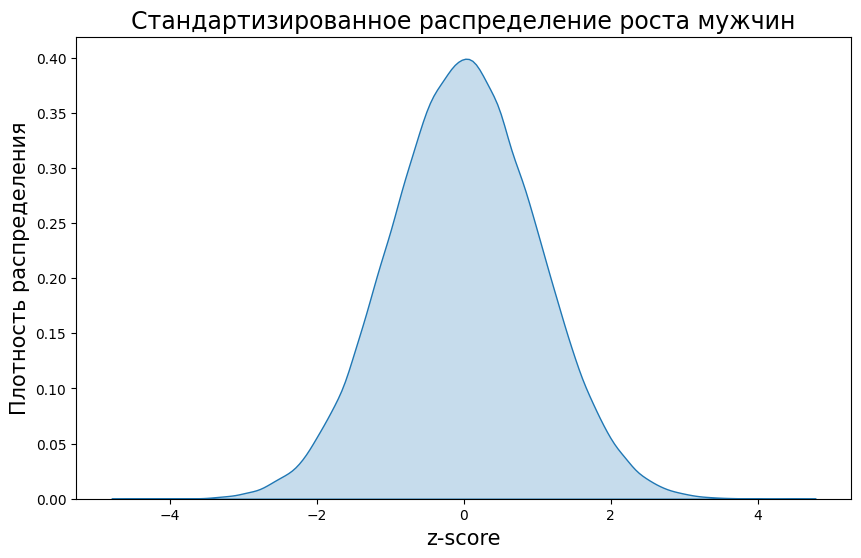

In [ ]:
# зададим размер графика
plt.figure(figsize = (10,6))

# построим график плотности
sns.kdeplot(height_men_standard, fill = True)

# добавим подписи
plt.xlabel('z-score', fontsize = 15)
plt.ylabel('Плотность распределения', fontsize = 15)
plt.title('Стандартизированное распределение роста мужчин', fontsize = 17)

plt.show()

In [ ]:
# импортируем класс StandardScaler
from sklearn.preprocessing import StandardScaler

# создаем объект этого класса
scaler = StandardScaler()

# применяем метод .fit_transform() к данным о росте, предварительно превратив их в двумерный массив
scaled_height_men = scaler.fit_transform(height_men.reshape(-1, 1))

# убираем второе измерение
scaled_height_men = scaled_height_men.flatten()

# и сравниваем получившийся результат с ранее стандартизированными данными
np.array_equiv(height_men_standard, scaled_height_men)

True

In [ ]:
# сразу создадим стандартное нормальное распределение
st_norm = np.random.standard_normal(10000)
st_norm[:10]

array([-0.76366945, -1.11864174, -0.77088274,  0.96929238, -0.69869956,
       -1.34853749, -0.94994848,  0.99902749,  0.30575659, -0.45619504])

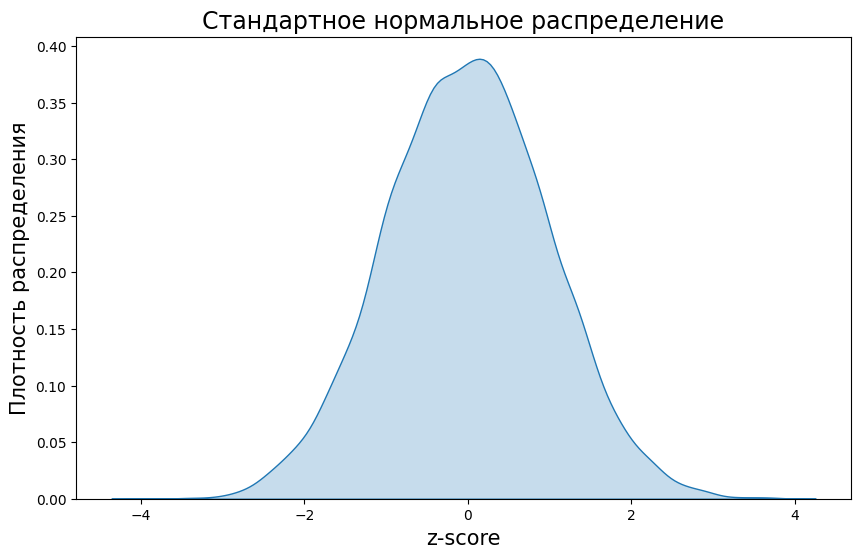

In [ ]:
# зададим размер графика
plt.figure(figsize = (10,6))

# построим график плотности
sns.kdeplot(st_norm, fill = True)

# добавим подписи
plt.xlabel('z-score', fontsize = 15)
plt.ylabel('Плотность распределения', fontsize = 15)
plt.title('Стандартное нормальное распределение', fontsize = 17)

plt.show()

In [ ]:
# создаваемый массив может быть многомерным
np.random.standard_normal((2, 3))

array([[-0.40187015, -0.0797878 , -0.21066058],
       [-0.70034594,  0.10488661,  0.85464581]])

In [ ]:
# вычислим z-score, соответствующий 95 процентам площади под кривой
# loc = 0, scale = 1 можно не указывать, это параметры по умолчанию
zscore = norm.ppf(0.95)
zscore

1.6448536269514722

In [ ]:
# убедиться в верности результата можно с помощью функции распределения
norm.cdf(zscore)

0.95

###### Критерии нормальности

Probability plot

In [ ]:
# вначале отсортируем данные о росте
height_men_srt = sorted(height_men)

# рассчитаем длину массива
n = len(height_men_srt)

# вычислим накопленную вероятность
cum_probability = [(i - 0.375)/(n + 0.25) for i in range(1, n + 1)]

# рассчитаем квантили, как если бы данные были нормально распределены
quantiles = norm.ppf(cum_probability)

In [ ]:
# как и должно быть, накопленная вероятность - это значения от 0 до 1
cum_probability[0], cum_probability[-1]

(6.249984375039063e-06, 0.999993750015625)

In [ ]:
# также посмотрим на соответствующие им квантили
quantiles[0], quantiles[-1]

(-4.368680139037586, 4.368680139037566)

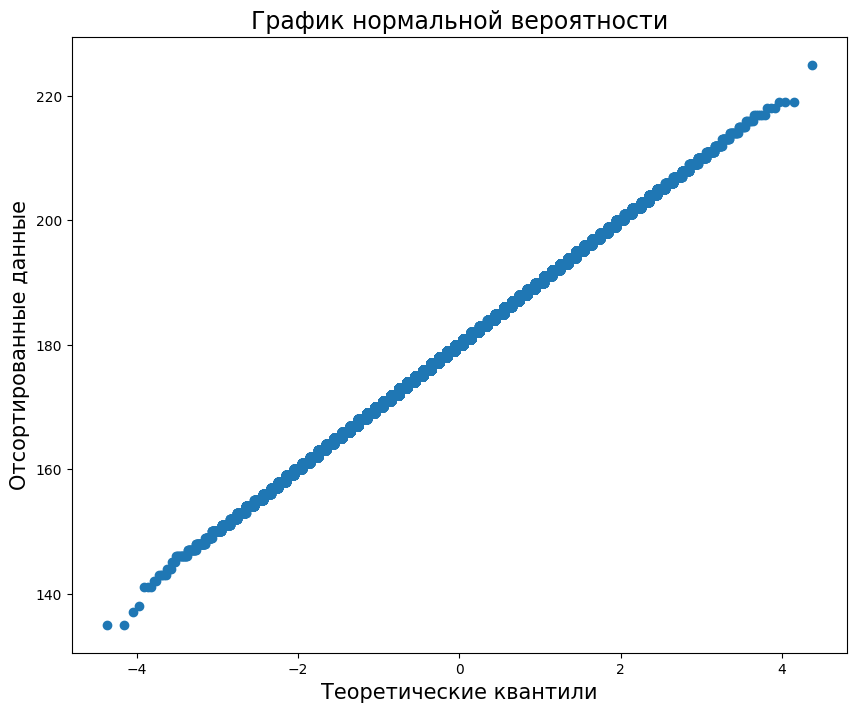

In [ ]:
# зададим размер графика
plt.figure(figsize = (10,8))

# на точечной диаграмме по оси x разместим теоретические квантили
# по оси y - отсортированные по возрастанию данные
plt.scatter(quantiles, height_men_srt)

# добавим подписи
plt.xlabel('Теоретические квантили', fontsize = 15)
plt.ylabel('Отсортированные данные', fontsize = 15)
plt.title('График нормальной вероятности', fontsize = 17)

plt.show()

In [ ]:
# можно также воспользоваться функцией probplot() модуля stats библиотеки scipy
from scipy.stats import probplot

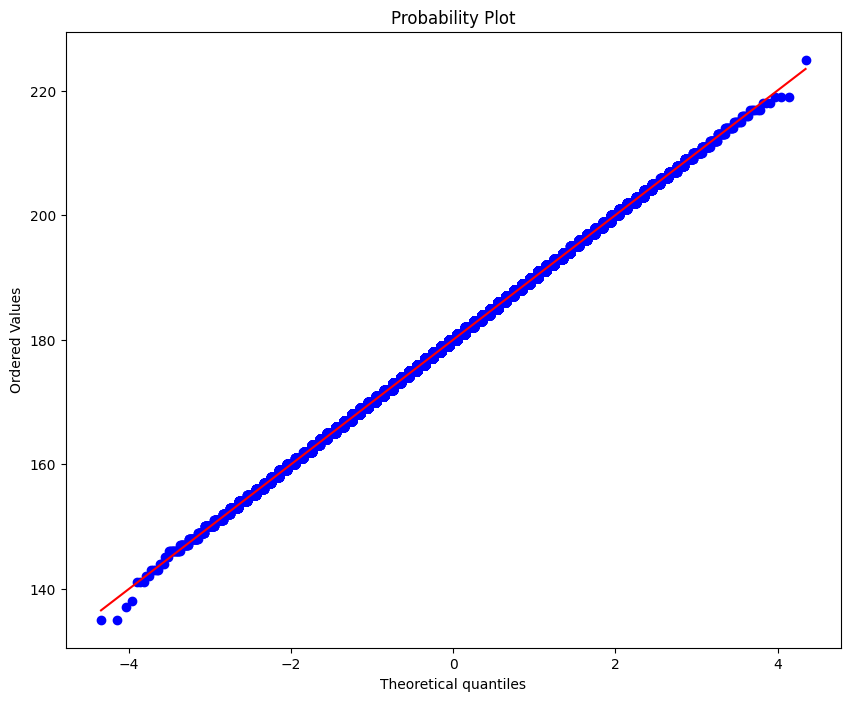

In [ ]:
plt.figure(figsize = (10,8))

# параметр dist = 'norm' указывает на сравнение данных с нормальным распределением
# plot = plt строит график с помощью matplotlib.pyplot
probplot(height_men, dist = 'norm', plot = plt)

plt.show()

In [ ]:
# функция probplot() при параметрах plot = None, fit = False возвращает два массива:
# квантили и отсортированные данные, возьмем первый массив [0]
quantiles = probplot(height_men, dist = 'norm', plot = None, fit = False)[0]

# и посмотрим на первое и последнее значения
quantiles[0], quantiles[-1]

(-4.346021549886044, 4.346021549886044)

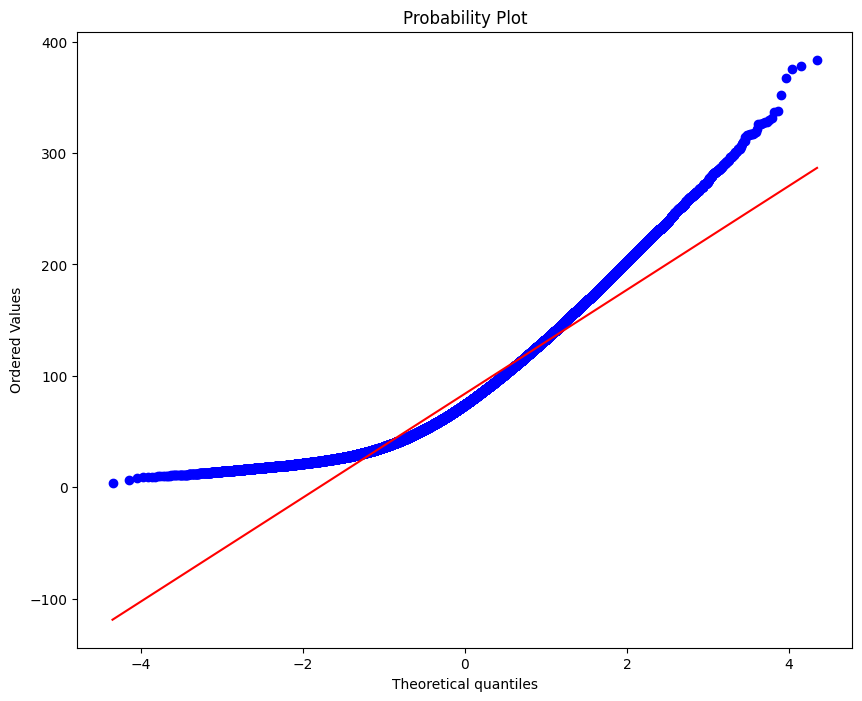

In [ ]:
# построим график нормальной вероятности для распределения зарплат
plt.figure(figsize = (10,8))
probplot(salaries, dist = 'norm', plot = plt)
plt.show()

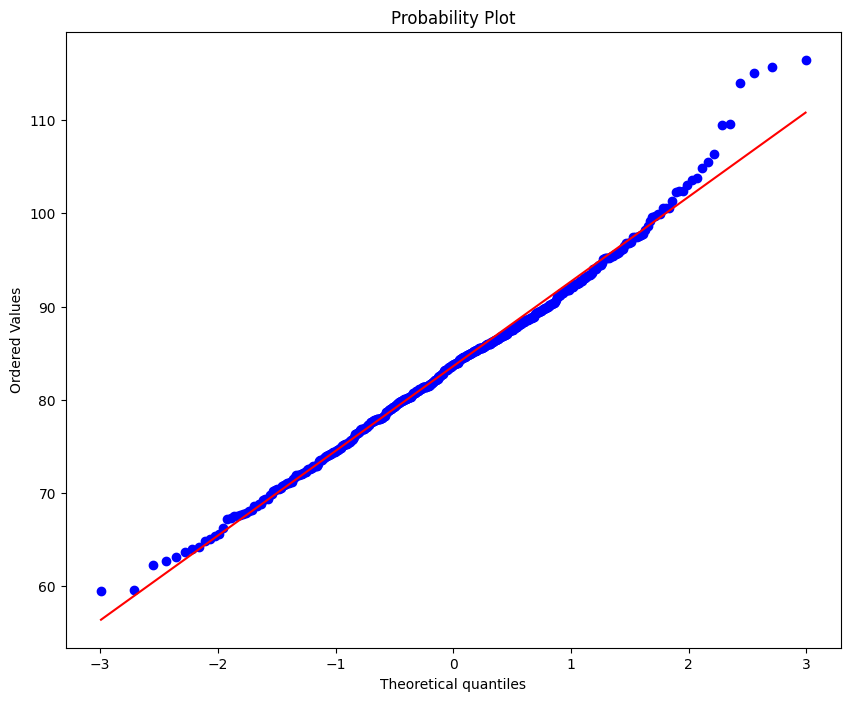

In [ ]:
# снова воспользуемся функцией sample_means() с параметрами n_samples = 500, sample_size = 30
sampling_dist = sample_means(salaries, 500, 30, replace = False, random_state = 42)

# построим график нормальной вероятности
plt.figure(figsize = (10,8))
probplot(sampling_dist, dist = 'norm', plot = plt)
plt.show()

Тест Шапиро-Уилка (Shapiro-Wilk test)

In [ ]:
# вновь создадим данные о росте и зарплатах с меньшим количеством элементов
np.random.seed(42)
height_men = np.round(np.random.normal(180, 10, 1000))

salaries = skewnorm.rvs(a = 20, loc = 20, scale = 80, size = 1000, random_state = 42)

In [ ]:
# импортируем функцию shapiro()
from scipy.stats import shapiro

# проведем тест на нормальность для распределения данных о росте
_, p_value = shapiro(height_men)
p_value

0.17031297087669373

In [ ]:
# проведем тест на нормальность для распределения данных о зарплате
_, p_value = shapiro(salaries)
p_value

1.3727537853780034e-21

###### Нормальное приближение

Теорема Муавра-Лапласа

$$ B(n, p) \sim N(np, \sqrt{np(1-p)}) $$

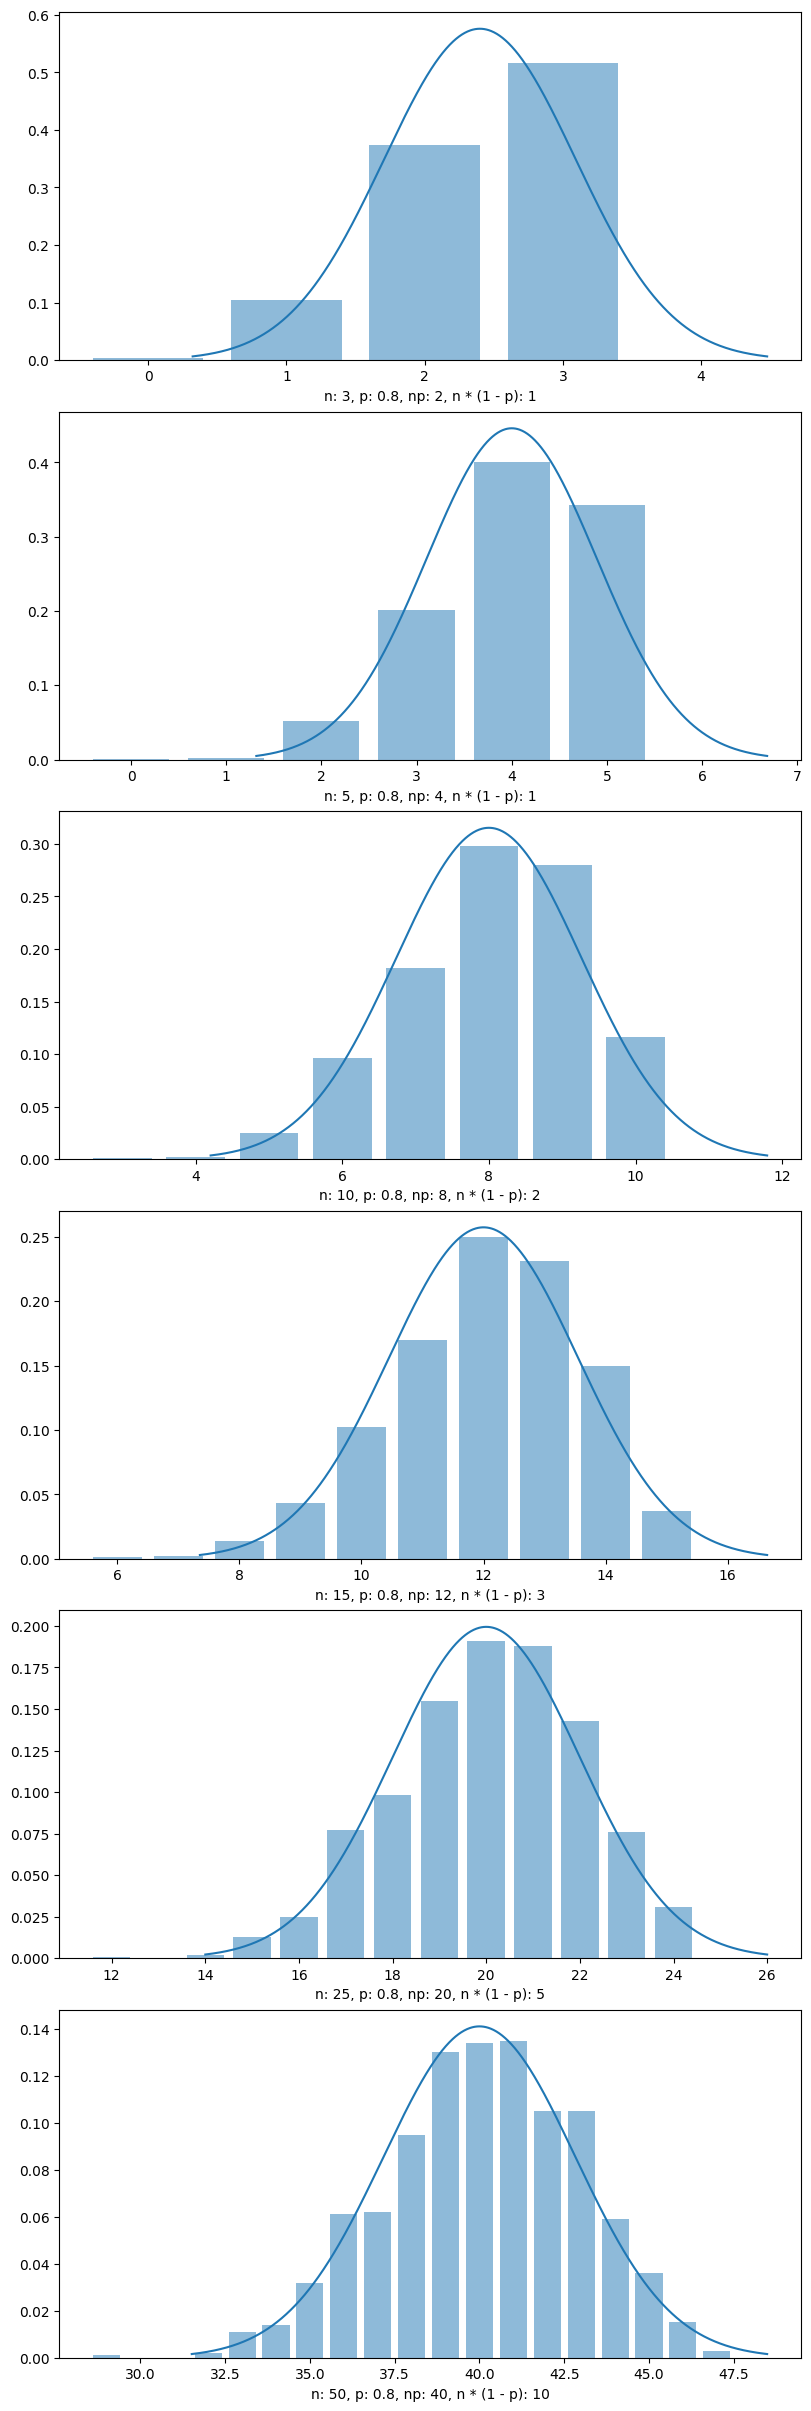

In [ ]:
# создадим список с количеством испытаний (подбрасываний монеты)
n_list = [3, 5, 10, 15, 25, 50]

# подграфики будут расположены в одном столбце с количеством строк,
# равном длине списка n_list
fig, ax = plt.subplots(nrows = len(n_list),
                       ncols = 1,
                       # размер графика также будет определяться длиной списка n_list
                       figsize = (8, 4 * len(n_list)),
                       # constrained_layout регулирует пространство между подграфиками
                       constrained_layout = True)

# пройдемся по списку n_list
for i, n in enumerate(n_list):

  # зададим вероятность успеха
  p = 0.8
  # и проверим выполняются ли условия при заданных p и n
  cond1, cond2 = n * p, n * (1 - p)

  # сгенерируем биномиальное распределение с заданными p и n
  np.random.seed(42)
  res = np.random.binomial(n = n, p = p, size = 1000)
  # запишем успешные серии подбрасываний и их количество
  successes, counts = np.unique(res, return_counts = True)

  # с помощью столбчатой диаграммы выведем относительную частоту каждого значения случайной величины
  ax[i].bar(successes, counts / len(res), alpha = 0.5)
  # в подписи к графикам выведем n, p, а также результат проверки условий
  ax[i].set_xlabel('n: {}, p: {}, np: {}, n * (1 - p): {}'.format(n, p, round(cond1), round(cond2)))

  # рассчитаем среднее значение и СКО согласно теореме Муавра-Лапласа
  mean, std = n * p, np.sqrt(n * p * (1 - p))
  # создадим 1000 точек в +/- 3 СКО от среднего значения
  x = np.linspace(mean - 3 * std, mean + 3 * std, 1000)
  # найдем точки на оси y по формуле Гаусса
  f_norm = norm.pdf(x, mean, std)
  # построим график плотности нормального распределения
  ax[i].plot(x, f_norm)

  # дополнительно можно вывести "идеальное" биномиальное распределение с помощью функции binom()
  # from scipy.stats import binom
  # x2 = np.arange(n)
  # binom_p = binom.pmf(x2, n, p)
  # ax[i].stem(x2, binom_p, use_line_collection = True)

plt.show()

Поправка на непрерывность распределения

$$ B(3; 0,5) \sim N(1,5; 0,75) $$

$$ P_B(X \leq 1) \sim P_N(X < 1,5) $$

In [ ]:
# передадим методу .cdf() границу, среднее значение (loc) и СКО (scale)
area = norm.cdf(1.5, loc = 1.5, scale = 0.75)

# на выходе мы получим площадь под кривой
area

0.5

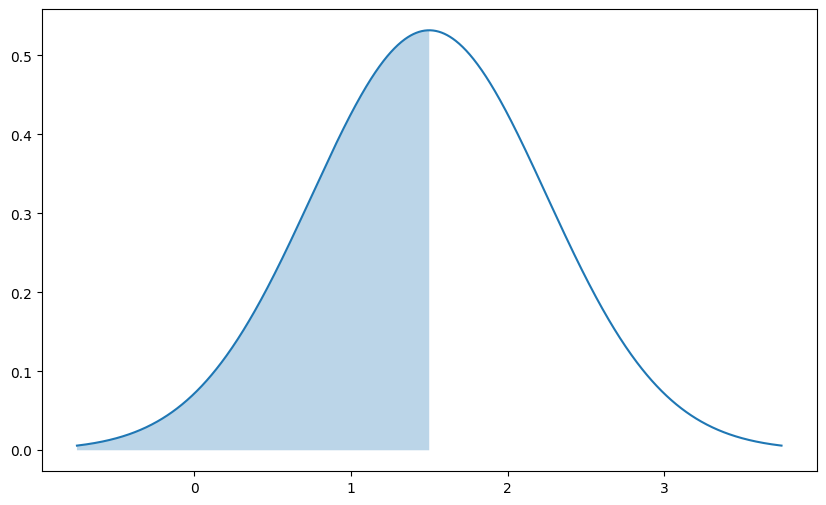

In [ ]:
# зададим размер графика
plt.figure(figsize = (10,6))

# пропишем среднее значение и СКО
mean, std = 1.5, 0.75

# создадим пространство из 1000 точек в диапазоне +/- трех СКО от среднего значения
x = np.linspace(mean - 3 * std, mean + 3 * std, 1000)

# рассчитаем зачения по оси y с помощью метода .pdf()
# т.е. функции плотности вероятности
f = norm.pdf(x, mean, std)

# и построим график
plt.plot(x, f)

# дополнительно создадим создадим точки на оси x для закрашенной области
px = x = np.linspace(mean - 3 * std, mean, 1000)

# и заполним в пределах этих точек по оси x пространство
# от кривой нормального распределения до оси y = 0
plt.fill_between(px, norm.pdf(px, mean, std), alpha = 0.3)

# выведем оба графика на экран
plt.show()

$$ P_B(X = 2) \sim P_N(1,5 < X < 2,5) $$

In [ ]:
# передадим методу .cdf() границу, среднее значение (loc) и СКО (scale)
area = norm.cdf(2.5, loc = 1.5, scale = 0.75) - norm.cdf(1.5, loc = 1.5, scale = 0.75)

# на выходе мы получим площадь под кривой
area

0.4087887802741321

In [ ]:
# рассчитаем биномиальную вероятность P(X = 2)
3/8

0.375

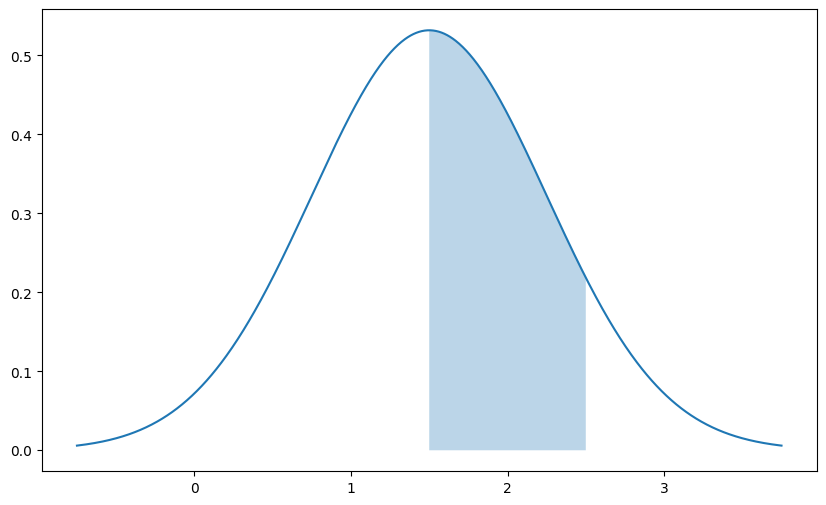

In [ ]:
# зададим размер графика
plt.figure(figsize = (10,6))

# пропишем среднее значение и СКО
mean, std = 1.5, 0.75

# создадим пространство из 1000 точек в диапазоне +/- трех СКО от среднего значения
x = np.linspace(mean - 3 * std, mean + 3 * std, 1000)

# рассчитаем значения по оси y с помощью метода .pdf()
# т.е. функции плотности вероятности
f = norm.pdf(x, mean, std)

# и построим график
plt.plot(x, f)

# дополнительно создадим создадим точки на оси x для закрашенной области
px = x = np.linspace(1.5, 2.5, 1000)

# и заполним в пределах этих точек по оси x пространство
# от кривой нормального распределения до оси y = 0
plt.fill_between(px, norm.pdf(px, mean, std), alpha = 0.3)

# выведем оба графика на экран
plt.show()

Пример приближения

$$ B(n, p) = B(500; 0,02) \rightarrow P_B(X \geq 15) $$

In [ ]:
# импортируем объект binom из модуля stats библиотеки scipy
from scipy.stats import binom

# зададим параметры биномиального распределения
n, p = 500, 0.02

# метод .cdf() рассчитывает вероятность до значения включительно (!),
# таким образом, чтобы найти X >= 15,
# мы берем значения вплоть до 14 и вычитаем результат из единицы
1 - binom.cdf(14, n, p)

0.08135689951689384

$$ B(500; 0,02) \sim {\mathcal N}(10; \sqrt{9.8}) \rightarrow P_N(X > 14,5) $$

In [ ]:
# рассчитаем среднее значение и СКО
mean, std = n * p, np.sqrt(n * p * (1 - p))

# рассчитаем площадь под кривой слева от границы и вычтем результат из единицы
1 - norm.cdf(14.5, loc = mean, scale = std)

0.07529192313308641

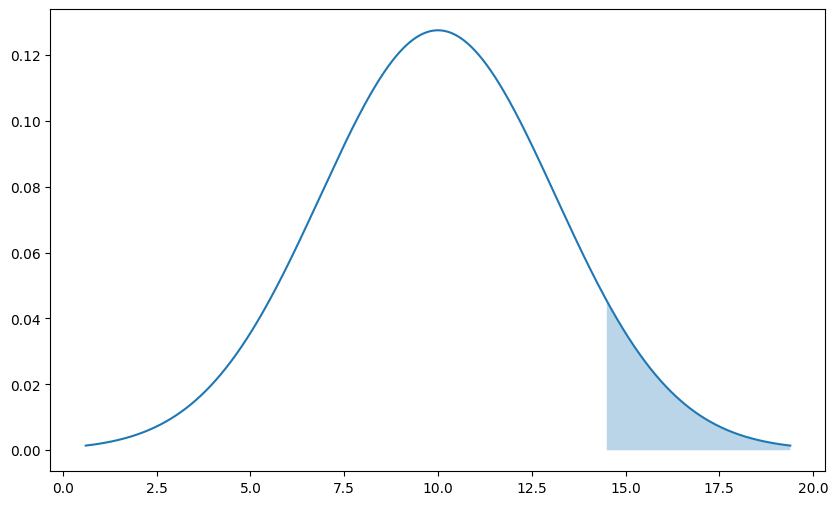

In [ ]:
# зададим размер графика
plt.figure(figsize = (10,6))

# создадим 1000 точек в +/- 3 СКО от среднего значения
x = np.linspace(mean - 3 * std, mean + 3 * std, 1000)
# найдем точки на оси y по формуле Гаусса
f_norm = norm.pdf(x, mean, std)
# построим график плотности нормального распределения
plt.plot(x, f_norm)

# дополнительно создадим точки на оси х для закрашенной области
px = np.linspace(14.5, mean + 3 * std, 1000)

# и заполним в пределах этих точек по оси x пространство
# от кривой нормального распределения до оси y = 0
plt.fill_between(px, norm.pdf(px, mean, std), alpha = 0.3)

plt.show()

### Комбинаторика в Питоне

#### `np.random.shuffle()` и `np.random.permutation()`

In [ ]:
# создадим массив и передадим его в функцию np.random.shuffle()
arr = np.array([1, 2, 3, 4, 5])

# сама функция выдала None, исходный массив при этом изменился
print(np.random.shuffle(arr), arr)

None [3 5 4 1 2]


In [ ]:
# еще раз создадим массив
arr = np.array([1, 2, 3, 4, 5])

# передав его в np.random.permutation(),
# мы получим перемешанную копию и исходный массив без изменений
np.random.permutation(arr), arr

(array([1, 2, 3, 5, 4]), array([1, 2, 3, 4, 5]))

Функция для разделения на обучающую и тестовую выборки

In [ ]:
# объявим функцию, которая принимает признаки X и целевую переменную y в формате
# массива Numpy или датафрейма
# дополнительно пропишем размер тестовой выборки с параметром по умолчанию 0,3
# и возможностью задать точку отсчета
def split_data(X, y, test_size = 0.3, random_state = None):

  # проверим, является ли X массивом Numpy с помощью функции isinstance()
  if isinstance(X, np.ndarray):
    # если да, превратим в датафрейм
    X = pd.DataFrame(X)
  # сделаем то же самое для y
  if isinstance(y, np.ndarray):
    y = pd.DataFrame(y)

  # еще один способ выполнить такую проверку
  # if type(X). __module__ == np. __name__:
  #   X = pd.DataFrame(X)
  # if type(y). __module__ == np. __name__:
  #   y = pd.DataFrame(y)

  # установим точку отсчета
  np.random.seed(random_state)

  # перемешаем индексы строк датасета X, не изменяя исходный массив
  indices = np.random.permutation(len(X))

  # определим количество строк, которые войдут в тестовую выборку
  # для этого умножим количество строк в X на долю тестовой выборки
  data_test_size = int(X.shape[0] * test_size)

  # начиная с этого количества (границы), будет обучающая выборка
  train_indices = indices[data_test_size:]
  # перед ним, тестовая
  test_indices = indices[:data_test_size]

  # с помощью метода .iloc() найдем в X все строки,
  # соответствующие индексам в переменных train_indices и test_indices
  X_train = X.iloc[train_indices]
  X_test = X.iloc[test_indices]

  # сделаем то же самое для y
  y_train = y.iloc[train_indices]
  y_test = y.iloc[test_indices]

  # выведем выборки в том порядке, в котором они выводятся в sklearn
  return X_train, X_test, y_train, y_test

In [ ]:
import pandas as pd

# импортируем данные о пациентах с диабетом
from sklearn.datasets import load_diabetes

# помещаем их в переменную data
data = load_diabetes()

# создаем два датафрейма
X = pd.DataFrame(data.data, columns = data.feature_names)
y = pd.DataFrame(data.target, columns = ['target'])

# для проверки работы функции можно также создать массивы Numpy
# X = data.data
# y = data.target

In [ ]:
# вызовем функцию split_data()
X_train, X_test, y_train, y_test = split_data(X, y, random_state = 42)

In [ ]:
# посмотрим на индексы строк в переменной X_train
X_train.head(3)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
108,0.019913,0.050680,0.045529,0.029894,-0.062111,-0.055802,-0.072854,0.026929,0.045604,0.040343
225,0.030811,0.050680,0.032595,0.049415,-0.040096,-0.043589,-0.069172,0.034309,0.063015,0.003064
412,0.074401,-0.044642,0.085408,0.063187,0.014942,0.013091,0.015505,-0.002592,0.006207,0.085907


In [ ]:
# теперь посмотрим на y_train
y_train.head(3)

,target
108,232.0
225,208.0
412,261.0


#### Модуль itertools

##### Перестановки

###### Перестановки без замены

1. Перестановки без повторений

In [ ]:
# импортируем модуль math
import math

# передадим функции factorial() число 3
math.factorial(3)

6

In [ ]:
# импортируем модуль itertools
import itertools

# создадим строку из букв A, B, C
x = 'ABC'
# помимо строки можно использовать и список
# x = ['A', 'B', 'C']

# и передадим ее в функцию permutations()
# так как функция возвращает объект itertools.permutations,
# для вывода результата используем функцию list()
list(itertools.permutations(x))

[('A', 'B', 'C'),
 ('A', 'C', 'B'),
 ('B', 'A', 'C'),
 ('B', 'C', 'A'),
 ('C', 'A', 'B'),
 ('C', 'B', 'A')]

In [ ]:
# чтобы узнать количество перестановок, можно использовать функцию len()
len(list(itertools.permutations(x)))

6

In [ ]:
# теперь элементов исходного множества шесть
x = 'ABCDEF'

# чтобы узнать, сколькими способами их можно разместить на трех местах,
# передадим параметр r = 3 и выведем первые пять элементов
list(itertools.permutations(x, r = 3))[:5]

[('A', 'B', 'C'),
 ('A', 'B', 'D'),
 ('A', 'B', 'E'),
 ('A', 'B', 'F'),
 ('A', 'C', 'B')]

In [ ]:
# посмотрим на общее количество таких перестановок
len(list(itertools.permutations(x, r = 3)))

120

2. Перестановки с повторениями

In [ ]:
# импортируем необходимые библиотеки
import itertools
import numpy as np
import math

# объявим функцию permutations_w_repetition(), которая будет принимать два параметра
# x - строка, список или массив Numpy
# r - количество мест в перестановке, по умолчанию равно количеству элементов в x
def permutations_w_repetition(x, r = len(x)):

  # если передается строка,
  if isinstance(x, str):
    # превращаем ее в список
    x = list(x)

  # в числителе рассчитаем количество перестановок без повторений
  numerator = len(list(itertools.permutations(x, r = r)))

  # для того чтобы рассчитать знаменатель найдем,
  # сколько раз повторяется каждый из элементов
  _, counts = np.unique(x, return_counts = True)

  # объявим переменную для знаменателя
  denominator = 1

  # и в цикле будем помещать туда произведение факториалов
  # повторяющихся элементов
  for c in counts:

      # для этого проверим повторяется ли элемент
      if c > 1:

        # и если да, умножим знаменатель на факториал повторяющегося элемента
        denominator *= math.factorial(c)

  # разделим числитель на знаменатель
  # деление дает тип float, поэтому используем функцию int(),
  # чтобы результат был целым числом
  return int(numerator/denominator)

In [ ]:
# создадим строку со словом "молоко"
x = 'МОЛОКО'

# вызовем функцию
permutations_w_repetition(x)

120

###### Перестановки с заменой

In [ ]:
# посмотрим, сколькими способами можно выбрать два сорта мороженого
list(itertools.product(['Ваниль', 'Клубника'], repeat = 2))

[('Ваниль', 'Ваниль'),
 ('Ваниль', 'Клубника'),
 ('Клубника', 'Ваниль'),
 ('Клубника', 'Клубника')]

In [ ]:
# посмотрим на способы переставить с заменой два элемента из четырех
list(itertools.product('ABCD', repeat = 2))

[('A', 'A'),
 ('A', 'B'),
 ('A', 'C'),
 ('A', 'D'),
 ('B', 'A'),
 ('B', 'B'),
 ('B', 'C'),
 ('B', 'D'),
 ('C', 'A'),
 ('C', 'B'),
 ('C', 'C'),
 ('C', 'D'),
 ('D', 'A'),
 ('D', 'B'),
 ('D', 'C'),
 ('D', 'D')]

In [ ]:
# убедимся, что таких способов 16
len(list(itertools.product('ABCD', repeat = 2)))

16

##### Сочетания

In [ ]:
# возьмем пять элементов
x = 'ABCDE'

# и найдем способ переставить два элемента из этих пяти
list(itertools.permutations(x, r = 2))

[('A', 'B'),
 ('A', 'C'),
 ('A', 'D'),
 ('A', 'E'),
 ('B', 'A'),
 ('B', 'C'),
 ('B', 'D'),
 ('B', 'E'),
 ('C', 'A'),
 ('C', 'B'),
 ('C', 'D'),
 ('C', 'E'),
 ('D', 'A'),
 ('D', 'B'),
 ('D', 'C'),
 ('D', 'E'),
 ('E', 'A'),
 ('E', 'B'),
 ('E', 'C'),
 ('E', 'D')]

In [ ]:
# уменьшим на количество перестановок каждого типа r!
int(len(list(itertools.permutations(x, r = 2)))/math.factorial(2))

10

In [ ]:
# то же самое можно рассчитать с помощью функции combinations()
list(itertools.combinations(x, 2))

[('A', 'B'),
 ('A', 'C'),
 ('A', 'D'),
 ('A', 'E'),
 ('B', 'C'),
 ('B', 'D'),
 ('B', 'E'),
 ('C', 'D'),
 ('C', 'E'),
 ('D', 'E')]

In [ ]:
# посмотрим на количество сочетаний
len(list(itertools.combinations(x, 2)))

10

Сочетания с заменой

In [ ]:
# сколькими способами с заменой можно выбрать два элемента из двух
list(itertools.combinations_with_replacement('AB', 2))

[('A', 'A'), ('A', 'B'), ('B', 'B')]

In [ ]:
# очевидно, что без замены есть только один такой способ
list(itertools.combinations('AB', 2))

[('A', 'B')]

Биномиальные коэффициенты

In [ ]:
# дерево вероятностей можно построить с помощью декартовой степени
list(itertools.product('HT', repeat = 3))

[('H', 'H', 'H'),
 ('H', 'H', 'T'),
 ('H', 'T', 'H'),
 ('H', 'T', 'T'),
 ('T', 'H', 'H'),
 ('T', 'H', 'T'),
 ('T', 'T', 'H'),
 ('T', 'T', 'T')]

In [ ]:
# посмотрим, в скольких комбинациях выпадет две решки при трех бросках
comb = len(list(itertools.combinations('ABC', 2)))
comb

3

In [ ]:
# вычислим вероятность выпадения двух орлов в трех бросках
# при вероятности выпадения орла 0,7
round(comb * (0.7 ** 2 * (1 - 0.7)** (3 - 2)), 3)

0.441

In [ ]:
from scipy.stats import binom

# то же самое можно вычислить с помощью функции вероятности (probability mass function, pmf)
# биномиального распределения библиотеки scipy
binom.pmf(k = 2, n = 3, p = 0.7).round(3)

0.441

### Дополнительные примеры

#### Матожадание и среднеее значение

Математическое ожидание

In [ ]:
# с помощью библиотеки scipy
from scipy.stats import binom

# для биномиального распределения со следующими параметрами
n, p = 3, 0.7

# рассчитаем матожидание и ожидаемую дисперсию
expected_value, variance = binom.stats(n, p, moments='mv')
expected_value, variance

(array(2.1), array(0.63))

Фактическое среднее значение

In [ ]:
# теперь с помощью модуля random
import numpy as np

# проведем миллион биномиальных экспрериментов
res = np.random.binomial(n = 3, p = 0.7, size = 1000000)

# и посмотрим на фактическое среднее значение и фактическую дисперсию
np.mean(res), np.var(res)

(2.100117, 0.6288295863109998)